# Исследование данных о российском кинопрокате

Цель работы: изучение рынка российского кинопроката и выявление текущих трендов, с выделением фильмов, которые получили государственную поддержку в отдельную группу с ее анализом.

Источник исходных данных - портал открытых данных Министерства культуры Российской Федерации.

## Открытие и изучение данных

Импорт библиотек и чтение файлов, необходимых для работы.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import CategoricalDtype

pd.options.display.float_format = '{:.2f}'.format

In [2]:
pth1_mov = '-/datasets/mkrf_movies.csv'
pth2_mov = 'https://-/mkrf_movies.csv'

pth1_show = '-/datasets/mkrf_show.csv'
pth2_show = 'https://-/mkrf_shows.csv'

if np.logical_and(os.path.exists(pth1_mov), os.path.isfile(pth1_mov)):
    df_movies = pd.read_csv(pth1_mov)
elif pth2_mov.endswith('.csv'):
    df_movies = pd.read_csv(pth2_mov)
else:
    print('Файл mkrf_movies не найден')

if np.logical_and(os.path.exists(pth1_show), os.path.isfile(pth1_show)):
    df_shows = pd.read_csv(pth1_show)
elif pth2_show.endswith('.csv'):
    df_shows = pd.read_csv(pth2_show)
else:
    print('Файл mkrf_movies не найден')

Получение общей информации о данных в первой таблице и оценка их типов с целью поиска колонки для объединения.

In [3]:
print(df_movies.dtypes)
print(df_movies.shape)
df_movies.head(3)

title                     object
puNumber                  object
show_start_date           object
type                      object
film_studio               object
production_country        object
director                  object
producer                  object
age_restriction           object
refundable_support       float64
nonrefundable_support    float64
budget                   float64
financing_source          object
ratings                   object
genres                    object
dtype: object
(7486, 15)


,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама"
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный"
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"


Аналогичная операция для второй таблицы

In [4]:
print(df_shows.dtypes)
print(df_shows.shape)
df_shows.head(3)

puNumber        int64
box_office    float64
dtype: object
(3158, 2)


,puNumber,box_office
0,111000113,2450.00
1,111000115,61040.00
2,111000116,153030013.40


В обеих таблицах присутствует лишь одна общая колонка - puNumber, однако в таблице df_movies она имеет строковый тип данных. Во-первых, это неоптимально, во-вторых, это не позволит объединить таблицы по данной колонке, соответственно, необходимо изменить тип данных на целочисленный. Заменим на ноль значение "нет", которое мешает преобразованию и произведем его при помощи метода astype().

In [5]:
df_movies['puNumber'].replace('нет', 0, inplace=True)
df_movies['puNumber'] = df_movies['puNumber'].astype('int')

Объединим обе таблицы, присвоив получившейся имя df. Перед тем, как переходить к предобработке данных, переименуем колонку 'puNumber' в 'pu_number' - для того, чтобы названия всех атрибутов имели одинаковую логику наименования (змеиный регистр без заглавных букв). Далее оценим содержимое итоговой таблицы при помощи info и вывода первых строк.

In [6]:
df = df_movies.merge(df_shows, on='puNumber', how='left')
df.rename(columns = {'puNumber': 'pu_number'}, inplace=True)
print(df.info())
df.head(4)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   pu_number              7486 non-null   int32  
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
 15  box_

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN


Судя по информации о итоговой таблице, полученной методом info(), можно сделать вывод, что объединение изначальных таблиц прошло корректно: сохранено общее количество строк от таблицы df_movies и перенесена вся информация о сборах (3158 записей).

Итоговое описание данных:
- title — название фильма;
- pu_number — номер прокатного удостоверения;
- show_start_date — дата премьеры фильма;
- type — тип фильма;
- film_studio — студия-производитель;
- production_country — страна-производитель;
- director — режиссёр;
- producer — продюсер;
- age_restriction — возрастная категория;
- refundable_support — объём возвратных средств государственной поддержки;
- nonrefundable_support — объём невозвратных средств государственной поддержки;
- financing_source — источник государственного финансирования;
- budget — общий бюджет фильма;
- ratings — рейтинг фильма на КиноПоиске;
- genres — жанр фильма;
- box_office — сборы в рублях.

## Предобработка данных

### Проверка типов данных

Дата премьеры фильма, возрастная категория и рейтинг фильма имеют строковый тип, их необходимо преобразовать в datetime, float и категориальный типы соответственно.

In [7]:
df['show_start_date'] = pd.to_datetime(df['show_start_date'], format='%Y.%m.%dT%H:%M:%S')

Перед преобразованием значений рейтинга в числовой тип, оценим какие значения принимает параметр.

In [8]:
df['ratings'].unique()

array(['7.2', '6.6', '6.8', '7.7', '8.3', '8.0', '7.8', '8.1', '7.1',
       '6.0', '7.4', '5.8', '8.7', '6.3', '6.9', '5.0', '4.3', '7.3',
       '7.0', '6.4', nan, '8.2', '7.5', '6.7', '7.9', '5.9', '6.2', '5.6',
       '6.5', '2.4', '7.6', '6.1', '8.6', '8.5', '8.8', '5.5', '5.1',
       '5.7', '5.4', '99%', '4.4', '4.5', '5.3', '4.1', '8.4', '2.6',
       '3.8', '4.6', '4.8', '4.0', '3.0', '1.6', '4.2', '5.2', '4.7',
       '4.9', '3.9', '2.7', '3.3', '2.9', '28%', '3.7', '1.4', '3.1',
       '97%', '3.5', '3.2', '2.8', '1.5', '2.1', '2.5', '9.2', '3.4',
       '1.1', '3.6', '83%', '64%', '91%', '94%', '62%', '79%', '90%',
       '19%', '88%', '1.0', '89%', '1.3', '1.9', '1.8', '1.2', '1.7',
       '9.0', '98%', '8.9', '9.1'], dtype=object)

Помимо значений по 10 бальной шкале также представлены оценки, выраженные в процентрах. Их необходимо привести к 10 бальной шкале в виде числа с точностью до 1 знака после запятой. Однако перед этим стоит подробнее изучить эти оценки: в глаза бросается большое количество оценок более 90%, что дает оценку в 9 баллов и более по 10 бальной шкале. Для начала выполним преобразование типа данных, содержащихся в колонке. Все оценки, выраженные в процентах, больше числа 10, и таким образом будут разделены с оценками, выставленными по 10 бальной шкале.

In [9]:
df['ratings'] = df['ratings'].str.rstrip('%').astype('float')

Выделим картины, рейтинг которых указан в процентах и проанализируем распределение оценок.

In [10]:
print('Количество фильмов с рейтингом, выраженным в процентах:', df.query('ratings > 10').shape[0])
df.query('ratings > 10')['ratings'].value_counts().sort_index()

Количество фильмов с рейтингом, выраженным в процентах: 29


19.00    1
28.00    1
62.00    1
64.00    1
79.00    2
83.00    3
88.00    3
89.00    1
90.00    1
91.00    3
94.00    3
97.00    3
98.00    2
99.00    4
Name: ratings, dtype: int64

Таких фильмов не много, всего 29, однако на себя обращает внимание значительное количество крайне высоких оценок, 90% и более. Чтобы удостовериться в аномальности этих цифр найдем следующие показатели: количество фильмов с оценкой от 9 баллов и более, долю фильмов, получивших оценку боле 8 баллов, а также средний рейтинг фильмов с соотвествующим типом его измерения (10 и 100 бальная шкала соответственно).

In [11]:
print('Количество фильмов с рейтингом от 9 баллов и выше:', df.query('ratings >= 9 and ratings <= 10').shape[0])
print('Доля фильмов с рейтингом выше 8 баллов от числа фильмов с рейтингом по 10 бальной шкале:', 
      round(df.query('ratings > 8 and ratings <= 10').shape[0] / 
            df.query('ratings > 0 and ratings <= 10').shape[0] * 100, 2), '%')
print('Средний рейтинг фильмов с оценкой по 10 бальной шкале:', 
      round(df.query('ratings > 0 and ratings <= 10')['ratings'].mean() ,2))
print('Средний рейтинг фильмов с оценкой в процентах:', round(df.query('ratings > 10')['ratings'].mean() ,2), '%')

Количество фильмов с рейтингом от 9 баллов и выше: 4
Доля фильмов с рейтингом выше 8 баллов от числа фильмов с рейтингом по 10 бальной шкале: 4.14 %
Средний рейтинг фильмов с оценкой по 10 бальной шкале: 6.48
Средний рейтинг фильмов с оценкой в процентах: 84.86 %


Среднему рейтингу выборки фильмов с оценкой в процентах соответсвует около всего 4% фильмов из общей выборки (с оценкой, выраженной в 10 бальной шкале). Такие оценки выглядят неправдоподобно, и, учитывая их незначительное количество, целесообразно исключить их из рабочего набора данных. Однако перед их удалением проверим, не включены ли эти фильмы в выборку картин, получивших государственную поддержку, т.к. первичный анализ показал их крайне низкое количество (332 ленты), что может дать почти 10% от такой выборки.

In [12]:
df.query('budget == budget and ratings > 10')

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
2146,Главный,111003415,2015-03-27 12:00:00+00:00,Художественный,"ООО ""Киностудия ""МАСТЕР""",Россия,Ю.Кара,Ю.Кара,«6+» - для детей старше 6 лет,0.00,10000000.00,40000000.00,Министерство культуры,94.00,"фантастика,боевик,комедия",334750.00
3139,Я умею вязать,111019615,2015-11-27 12:00:00+00:00,Художественный,"ООО ""Белое Зеркало""",Россия,Н.Степанова при участии С.Иванова,"С.Кикнавелидзе, Д.Улюкаев",«16+» - для детей старше 16 лет,0.00,4700000.00,14462464.00,Министерство культуры,90.00,драма,801370.00


Всего два фильма. Поиск их рейтинга в открытых источниках показывает, что указанная в процентах оценка явно некорректна. Соответственно удаляем все записи с фильмами, рейтинг которых указан в процентах. Сразу после этого проверим корректность удаления строк с аномальными данными.

In [13]:
df = df.loc[(df['ratings'] <= 10)|(df['ratings'].isna()==True)]
df.query('ratings > 10').shape[0]

0

Для преобразования возрастных категорий посмотрим, какие уникальные значения может принимать данный атрибут.

In [14]:
df['age_restriction'].unique()

array(['«18+» - запрещено для детей', '«6+» - для детей старше 6 лет',
       '«12+» - для детей старше 12 лет',
       '«16+» - для детей старше 16 лет',
       '«0+» - для любой зрительской аудитории'], dtype=object)

Заменим тип данных возрастных категорий на категориальный.  Для этого предварительно упростим строковые обозначения до аналогичных будущем категориям.

In [15]:
df['age_restriction'].replace(['«0+» - для любой зрительской аудитории', '«6+» - для детей старше 6 лет',
                              '«12+» - для детей старше 12 лет', '«16+» - для детей старше 16 лет', '«18+» - запрещено для детей'], 
                              ['0+', '6+', '12+', '16+', '18+'], inplace=True)
age_type = CategoricalDtype(categories=['0+', '6+', '12+', '16+', '18+'], ordered=True)
df['age_restriction'] = df['age_restriction'].astype(age_type)

### Изучение пропусков в датафрейме

Для упрощения оценки количества пропусков при помощи цикла, который отфильтрует колонки, имеющие пропущенные значения, создадим таблицу, содержащую информацию о количестве заполненных значений и пропусков, их процентное соотношение и количество значений, равное нулю (для количественных значений.

In [16]:
attribute_list = df.columns
columns_name = []
len_list = []
nan_count_list = []
ratio_nan_list = []
zero_count_list = []
for attribute in attribute_list:
    if (df[df[attribute].isna() == True].shape[0]) != 0:
        columns_name.append(attribute)
        len_list.append(df[attribute].count())
        nan_count_list.append(df[df[attribute].isna() == True].shape[0])
        ratio_nan_list.append(df[df[attribute].isna() == True].shape[0] / df.shape[0] * 100)
        zero_count_list.append(df[df[attribute] == 0].shape[0])
    
zero_attribute_table = pd.DataFrame((len_list, nan_count_list, ratio_nan_list, zero_count_list), index=[
    'value_count', 'NaN_count', 'NaN_ratio', 'zero_count'], columns=columns_name)
zero_attribute_table

,film_studio,production_country,director,producer,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
value_count,7439.00,7455.00,7448.00,6889.00,330.00,330.00,330.00,330.00,6490.00,6484.00,3143.00
NaN_count,18.00,2.00,9.00,568.00,7127.00,7127.00,7127.00,7127.00,967.00,973.00,4314.00
NaN_ratio,0.24,0.03,0.12,7.62,95.57,95.57,95.57,95.57,12.97,13.05,57.85
zero_count,0.00,0.00,0.00,0.00,219.00,9.00,17.00,0.00,0.00,0.00,23.00


Во-первых, обращает на себя внимание черезвычайно большое количество пропусков в атрибутах, несущих информацию о государственном финансировании. Необходимо убедиться, что все пропуски в этих категориях находятся в одних и тех же строках. Для этого посчитаем количеством строк, в которых пропуски у рассматриваемых атрибутов отсуствуют.

In [17]:
df[(df['refundable_support'].isna() == False)&
   (df['nonrefundable_support'].isna() == False)&
   (df['budget'].isna() == False)&
   (df['financing_source'].isna() == False)].shape[0]

330

Гипотеза подтвердилась. В строках, имеющих информацию о государственном финансировании, соответствующие атрибуты заполнены полностью, эти данные пригодны для анализа без дополнительной обработки. Однако количество таких строк крайне мало - пропуски составляют более 95%, соответственно заполнять пустые значения какими-либо рассчетными не имеет никакого смысла, это может кардинально исказить результаты анализа.

Незначительное количество пропусков имеют атрибуты с информацией о студии и стране-производителе, режиссёре, однако заполнить эти значения по имеющейся в данных информации невозможно. Немного больше пропусков в информации о продюсере, но ситуация с заполнением пропусков в этой колонке аналогичная. Значительное количество пропусков, около 13%, в колонках, содержащих информацию о жанре и рейтинге фильмов. Наконец, данные о сборах пропущены в чрезвычайно большом количе строк, более 50%. Теоретически, такую недостающую информацию как имя режиссера или жанр фильма, возможно извлечь из каких-либо внешних баз данных, заполнение же таких пропусков типовыми значениями лишь внесет искажения в результаты анализа. Аналогичная ситуация с пропусками в числовых значениях - учитывая, что каждый фильм является уникальникальным произведением киноискусства, количество факторов, влияющих на рейтинг и сборы картины обширно, и заполнение расчетными данными, даже при учете всей имеющейся у нас информации, будет слишком грубым приближением. Поэтому проведем анализ по имеющимся данным и не будем заполнять пропущенные значения.

### Изучение дубликатов в датафрейме

Для начала проверим наличие полностью дублируюихся строк.

In [18]:
df.duplicated().sum()

0

Полностью дублирующиеся строки отсутствуют. Предположим, что некоторые фильмы могли выходить в прокат больше одного раза, получая при этом новые прокатные удостоверения. Проверим это, а также проверим наличие дублей по номеру прокатного удостоверения - т.к. номер удостоверения по сути является уникальным идентификатором, и он не должен повторяться.

In [19]:
print('Количество дубликатов по названию фильма:', df['title'].duplicated().sum(),
      'и их процент от общего числа записей:', round(df['title'].duplicated().sum() / df.shape[0] * 100, 3), '%')
print('Количество дубликатов по номеру прокатного удостоверения:', df['pu_number'].duplicated().sum(),
     'и их процент от общего числа записей:', round(df['pu_number'].duplicated().sum() / df.shape[0] * 100, 3), '%')

Количество дубликатов по названию фильма: 714 и их процент от общего числа записей: 9.575 %
Количество дубликатов по номеру прокатного удостоверения: 2 и их процент от общего числа записей: 0.027 %


Помимо ожидаемых дубликатов по названию фильма, обнаружилось два дубликата по номеру прокатного удостовеления. Это явная аномалия, номера прокатных удостоверений не должны повторяться, таких дубликатов всего два, поэтому изучим их более внимательно.

In [20]:
df[df['pu_number'].duplicated() == True]

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
4639,Иоанна - женщина на папском престоле /По роман...,221154310,2010-12-17 12:00:00+00:00,Художественный,"Константин Фильм, А Эр Ди Дегето Фильм, Дюне ...",Германия - Великобритания - Италия - Испания,Зенке Вортманн,"Оливер Бербен, Дорис Д.Хайнце, Фарук Элтан",16+,NaN,NaN,NaN,NaN,7.60,"драма,мелодрама,история",NaN
5068,Анализируй то!,221054410,2010-05-25 12:00:00+00:00,Художественный,"Уорнер Бразерс, Виллидж Роадшоу Пикчерз, Эн-Пи...",США,Гарольд Реймис,"Джейн Розенталь, Паул Уэйнстейн",12+,NaN,NaN,NaN,NaN,6.80,"комедия,криминал",NaN


In [21]:
df.query('pu_number == 221054410 or pu_number == 221154310')

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
4638,Как жениться и остаться холостым,221154310,2010-12-17 12:00:00+00:00,Художественный,"Ше Вам, Скрипт Ассосье, Тэ Фэ 1 Фильм Продюксь...",Франция,Эрик Лартиго,"Амандин Било, Алан Шаба",16+,NaN,NaN,NaN,NaN,7.00,"мелодрама,комедия",NaN
4639,Иоанна - женщина на папском престоле /По роман...,221154310,2010-12-17 12:00:00+00:00,Художественный,"Константин Фильм, А Эр Ди Дегето Фильм, Дюне ...",Германия - Великобритания - Италия - Испания,Зенке Вортманн,"Оливер Бербен, Дорис Д.Хайнце, Фарук Элтан",16+,NaN,NaN,NaN,NaN,7.60,"драма,мелодрама,история",NaN
5067,Анализируй это!,221054410,2010-05-25 12:00:00+00:00,Художественный,"Уорнер Бразерс, Вилладж Роудшоу Филмз ЛТД",США-Австралия,ХЭрольд Рэмис,"Джейн Розенталь, Пола Уейнстейн",16+,NaN,NaN,NaN,NaN,7.40,"комедия,криминал",NaN
5068,Анализируй то!,221054410,2010-05-25 12:00:00+00:00,Художественный,"Уорнер Бразерс, Виллидж Роадшоу Пикчерз, Эн-Пи...",США,Гарольд Реймис,"Джейн Розенталь, Паул Уэйнстейн",12+,NaN,NaN,NaN,NaN,6.80,"комедия,криминал",NaN


Двум номерам прокатных удостоверений соответсвует по два разных фильма, причем у фильмов имеющих одинаковые номера удостоверения одинаковая дата выхода в прокат. Вероятно это вызвано какой-то технической ошибкой при заполнении базы. Учитывая единичный характер этой аномалии соответсвующие строки можно оставить в датасете.

### Изучение категориальных значений

Посмотрим, какие уникальные значения могут принимать категориальные значения, при небольшом количестве категорий, целесообразно будет перевести тип данных из строкового в категориальный.

In [22]:
df['type'].unique()

array(['Художественный', 'Анимационный', 'Прочие', 'Документальный',
       'Научно-популярный', ' Художественный', ' Анимационный',
       'Музыкально-развлекательный'], dtype=object)

Видим неявные дубликаты в виде некорректных наименований некоторых категорий, включающих пробел после названия. Удалим эти пробелы, а также приведем тип значения к категориальному.

In [23]:
df['type'] = df['type'].str.strip()
film_type = CategoricalDtype(categories=['Художественный', 'Анимационный', 'Документальный', 'Научно-популярный',
                                         'Музыкально-развлекательный', 'Прочие'])
df['type'] = df['type'].astype(film_type)

Изучим следующие признаки

In [24]:
df['financing_source'].unique()

array([nan, 'Министерство культуры', 'Фонд кино',
       'Министерство культуры, Фонд кино'], dtype=object)

Данный атрибут принимает только 3 возможных значения, целесообразно перевести тип данных в категориальный.

In [25]:
financing_type = CategoricalDtype(categories=['Министерство культуры', 'Фонд кино', 'Министерство культуры, Фонд кино'])
df['financing_source'] = df['financing_source'].astype(financing_type)

In [26]:
df['genres'].unique()

array(['боевик,драма,мелодрама', 'драма,военный',
       'фантастика,боевик,триллер', 'драма', 'мелодрама,комедия',
       'мюзикл,мелодрама,комедия', 'комедия,криминал',
       'боевик,триллер,детектив', 'боевик,драма,приключения',
       'драма,спорт', 'триллер,драма,мелодрама', 'комедия,мелодрама',
       'драма,мелодрама,комедия', 'драма,мелодрама', 'драма,история',
       'драма,мелодрама,семейный', 'комедия,мелодрама,криминал',
       'комедия', 'боевик,драма,криминал', 'драма,комедия',
       'ужасы,фантастика,комедия', 'мультфильм,короткометражка,мелодрама',
       'драма,криминал', 'мультфильм,фантастика,фэнтези',
       'триллер,драма,криминал', 'драма,мелодрама,биография',
       'драма,комедия,военный', 'фантастика,драма,детектив',
       'мюзикл,семейный', nan, 'военный,приключения,драма',
       'документальный,драма', 'драма,биография,история',
       'боевик,триллер,драма', 'фэнтези,боевик',
       'боевик,комедия,криминал', 'мюзикл,комедия,детский',
       'комедия,мел

Атрибут с названием жанра принимает большое количество различных вариантов. Причем количество непосредственно жанров относительно невелико, большое количество уникальных значений обусловлено различными комбинациями жанров для описания фильмов, включая варианты с одинаковым набором жанров, просто расположенных в различной последовательности. При использовании жанра в анализе у картин со сложным жанром целесообразно будет выделить основной.

И, наконец, необходимо проверить, есть ли пробелы вокруг фамилий режиссеров. Однако из-за огромного их количества нет смысла искать такие дубликаты вручную. Вместо этого применим метод .str.strip() и сравним количество уникальных значений до и после его применения.

In [27]:
print(len(df['director'].unique()))
df['director'] = df['director'].str.strip()
len(df['director'].unique())

4794


4784

Уникальных значений стало меньше, т.е., хотя дубликатов было и мало, тем не менее, они имели место быть.

Рассмотрим оставшиеся колонки, содержащие категориальные значения.

In [28]:
df['production_country'].value_counts()

США                                                                       2169
Россия                                                                    1804
СССР                                                                       347
Франция                                                                    301
Великобритания                                                             257
                                                                          ... 
Великобритания - США - Австралия - Ирландия - Германия - Куба - Канада       1
Аргентина - Мексика - Бразилия - Франция - США                               1
Швеция - США                                                                 1
Франция - Германия - Турция - Катар                                          1
Дания - Канада - Швеция - Франция - Германия - Великобритания - США          1
Name: production_country, Length: 946, dtype: int64

In [29]:
len(df[df['production_country'].str.contains('США', na=False, regex=False)]['production_country'].unique())

346

Страна производства задана 946 уникальными значениями, однако подавляющее большинство таких значений является комбинацией различных названий стран: 346 из 946 уникальных значений составляют различные комбинации, включающие США как один из составных элементов стоки. Аналогичную проблему мы видели в колонке, содержащей жанры фильмов, и скорее всего аналогичная ситуация повторится с информацией о студии-производителе и продюсере фильма.

In [30]:
print('Случайная выборка из 10 наименований студии-производителя фильма:', df['film_studio'].sample(10))
print('')
print('Случайная выборка из 10 ячеек с информацией о продюсере:', df['film_studio'].sample(10))

Случайная выборка из 10 наименований студии-производителя фильма: 6507                                                  NaN
1430    Европа Корпорейшн, Тэ Эф 1 Фильм Продюксьон, Э...
2377    Гоцман Груп, Эбболита Продакшн, Старстрим Инте...
477                                                Варп Х
4249    ХХ век Фокс, Дан Интертейнмент, Гиант Студиос,...
2013              Скрин Аустралиа, Эс Си Филмз Интернэшнл
2190    Дуэа Фильм, Комво Продуциони, Эр А И Синема, М...
3932        Нью Лайн Синема, Никкол Филмз, Уорнер Бразерс
3803                                       ООО "ГРИНСИТИ"
4928                                   Кор Контентс Медиа
Name: film_studio, dtype: object

Случайная выборка из 10 ячеек с информацией о продюсере: 5739                                   ООО "Мульт в кино"
5344    Парамаунт Пикчерз, Дэнвер энд Делайла Продакшн...
446                          Юниверсал Пикчерз, Рот Филмз
2083                                          Синемажинэр
4810    Рэдемпшн Пикчерз, Силве

Предположение подтвердилось, и для анализа данные категории в том виде, в котором они представлены в датасете не пригодны. Один из вариантов обработки подобных атрибутов - выделение основного (стоящего на первом месте в строке) элемента. Однако, так как вышерассмотренные атрибуты не будут использоваться в дальнейшем анализе, какая-либо их обработка нецелесообразна. 

### Проверка количественных значений

К количественным значениям относится информация о финансировании и сборах фильмов. В свою очередь, информация о финансировании содержит данные о государственном финансировании, которое входит в общий бюджет картины. Проверим имеющиеся данные на корректность: во-первых, общий бюджет не должен быть меньше объема государственной поддержки, во-вторых, сам бюджет не может быть нулевым.

In [31]:
print('Количество фильмов с нулевым бюджетом:', df[df['budget'] == 0].shape[0])
print('Количество фильмов с бюджетом меньше объема государственной поддержки:', 
      df[df['budget'] < (df['refundable_support'] + df['nonrefundable_support'])].shape[0])

Количество фильмов с нулевым бюджетом: 17
Количество фильмов с бюджетом меньше объема государственной поддержки: 17


Количество таких картин одинаково, вероятно эти списки совпадают и в анализируемых данных нет фильмов с ненулевым бюджетом, имеющих объем государственной поддержки больше значения суммарного бюджета. Проверим это.

In [32]:
(df[df['budget'] < (df['refundable_support'] + df['nonrefundable_support'])] == df[df['budget'] == 0])['pu_number'].sum()

17

Версия подтвердилась. Предположим, что такие фильмы были сняты исключительно на средства государственной поддержки, и их общий бюджет равен сумме государственных субсидий, а его сумма не указана из-за технической ошибки. В качестве критерия фальсифициремости этой гипитезы можно рассмотреть среднее и медианное значения бюджетов картин, пролучивших государственную поддержку. После этого, в силу малого количества проблемных картин, стоит изучить данные о реальных бюджетах по открытым источникам.

Выведем среднее и медиану бюджета в миллионах рублей по двум группам: картины, получавшие государственное финансирование, не включая аномальные фильмы с нулевым бюджетом, и собственно такие фильмы во второй группе, по которой общий бюджет считается равным сумме различных видов государственного финансирования.

In [33]:
df.query('budget != 0 and (refundable_support != 0 or nonrefundable_support != 0)')['budget'].agg(['mean', 'median']).round() / 1000000

mean     134.78
median    74.07
Name: budget, dtype: float64

In [34]:
(df.query('budget == 0')['refundable_support'] + df.query('budget == 0')['nonrefundable_support']).agg(['mean', 'median']).round() / 1000000

mean     81.88
median   70.00
dtype: float64

Мы видим практически равные медианные значения, и можно было бы предположить, что гипотеза подтвердилась, однако среднее отличается достаточно сильно - более чем на 60%, и причина такой разницы становится ясна при выборочном поиске реальных бюджетов конкретных фильмов из изучаемой выборки. Реальные бюджеты выше, т.е. гипотеза не подтверждается.

Теперь изучим распределение всех этих параметров, и начнем с бюджета. Для начала вызовем метод describe() дополненный 99% перцентилем.

In [35]:
df.query('budget > 0')['budget'].describe(percentiles=[.25, .5, .75, .99])

count          313.00
mean     134778924.84
std      191643121.41
min       15010000.00
25%       46154000.00
50%       74071918.00
75%      150008573.00
99%      924313035.80
max     2305074303.00
Name: budget, dtype: float64

Даже беглого взгляда на описательную статистику достаточно, чтобы сказать, что бюджет крайне не однородный параметр. Среднее почти вдвое выше медианы, максимум более чем в 2 раза выше 99% перцентиля, а также очень большая величина стандартного отклонения. Это говорит нам о наличии в данных некоторого количества фильмов с экстремально высоким бюджетом относительно диапазона нормальных значений. Для визуальной оценки распределения имеет смысл построить как гистрограмму, так и диаграмму размаха для определения диапазона статистически нормальных значений.

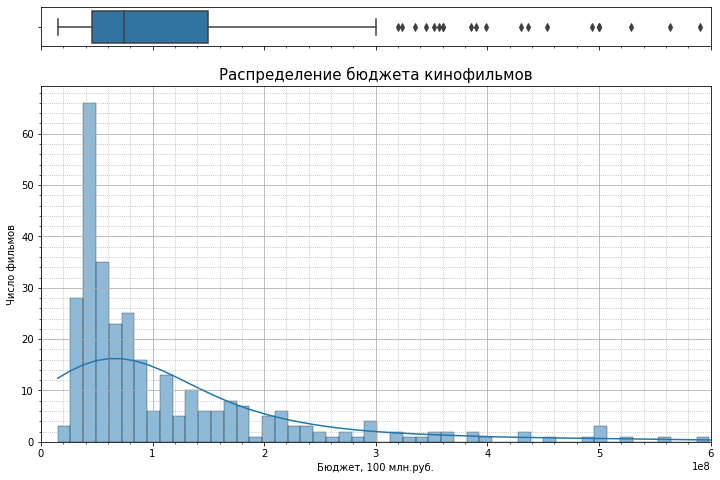

In [36]:
fig_bud, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': (.1, .9)}, figsize=(12, 8))
sns.boxplot(x=df.query('budget > 0')['budget'], ax=ax_box)
sns.histplot(x=df.query('budget > 0')['budget'], ax=ax_hist, bins=200, kde=True)
plt.title('Распределение бюджета кинофильмов', fontsize=15)
ax_box.set(xlabel='')
ax_hist.set(xlabel='Бюджет, 100 млн.руб.', ylabel='Число фильмов')
ax_hist.set_xlim(0,600000000)
plt.minorticks_on()
plt.grid(which='major')
plt.grid(which='minor', linestyle=':')

Гистрограмма имеет форму распределения Пуассона, основная масса значений находится в диапазоне до 200 миллионов, а четко выделяющийся пик в районе 40-50 миллионов, что совпадает с 25% перцентилем. Диапазон же нормальных значений параметра ограничивается 600 миллионами, после которого идет хвост немногочисленных выбросов. При этом экстремумы выглядят вполне реальными значениями, бюджет в 15 миллионов реален для небольшого, особенно мультипликационного фильма, а 2 миллиарда рублей адекватно большому проекту с дорогим актерским составом. На всякий случай проверим это и посмотрим на строки, соотвествующими значениями.

In [37]:
extr_budget = df.query('budget > 0')
extr_budget[(extr_budget['budget'] == extr_budget['budget'].min()) | (extr_budget['budget'] == extr_budget['budget'].max())]

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
7042,Ленин Неизбежность,111010619,2019-07-01 12:00:00+00:00,Художественный,"ООО ""Студия ""Рой""",Россия,В.Хотиненко,"В.Хотиненко, Д.Литвинов",16+,0.00,10000000.00,15010000.00,Министерство культуры,5.40,"драма,история,биография",1957979.50
7114,Тайна Печати Дракона,111012819,2019-09-12 12:00:00+00:00,Художественный,"ООО ""Кинокомпания ""СТВ""; ООО ""РФГ Корп""; ООО ""...",Россия-Китай,О.Степченко,"С.Сельянов, А.Петрухин",6+,180000000.00,90000000.00,2305074303.00,Фонд кино,5.80,"приключения,фэнтези",333597059.59


Простая проверка данных в открытых источниках показала соответствие реальных бюджетов тем, что содержатся в исследуемых данных. Вероятнее всего некорректные данные о бюджете отсутствуют.

Далее рассмотрим сведения о предоставляемой государством финансовой поддержке, как возвратной, так и невозвратной.

,refundable_support,nonrefundable_support
count,111.00,321.00
mean,35486486.49,50613670.75
std,31972875.36,60334540.85
min,3500000.00,3000000.00
25%,15000000.00,25000000.00
50%,25000000.00,30000000.00
75%,50000000.00,45000000.00
max,180000000.00,400000000.00


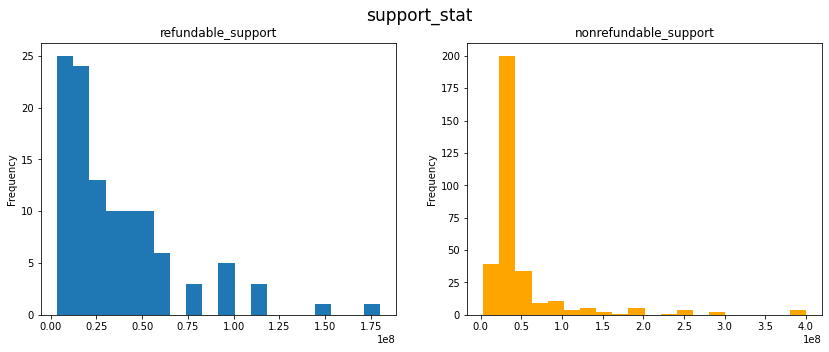

In [38]:
display(df.query('refundable_support > 0')['refundable_support'].describe().to_frame().join(
    df.query('nonrefundable_support > 0')['nonrefundable_support'].describe()))

fig_sup, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 5), gridspec_kw={'width_ratios': (.5, .5)})
plt.suptitle('support_stat', fontsize=17)
df.query('refundable_support > 0')['refundable_support'].plot(kind='hist', bins=20, title='refundable_support', ax=axs[0])
df.query('nonrefundable_support > 0')['nonrefundable_support'].plot(kind='hist', bins=20, title='nonrefundable_support', color='orange', ax=axs[1])
plt.show()

Что бросается в глаза при первом взгляде, так это то, что невозвратная поддержка пользуется гораздо большей популярностью и охотно применяется государством: ее выдают почти втрое чаще, и суммы выше, чем у возвратной. При этом значения возвратной более однородны и имеют плавно снижающийся (по сравнению с гистограммой невозвратной поддержки) пик, начинающийся от минимальных значений. Пик гистограммы объема невозвратной поддержки значительно более выраженный, с длинным хвостом, прижатым к оси абсцисс и уходящим вправо: несмотря на популярность такого вида финансирования государство не торопится раздавать большие суммы, значительная часть вливаний находится в диапазоне от медианы до средней и далека от максимальных значений. При этом как и в случае и бюджетом, экстремумы параметров выглядят реалистично, и строить диаграмму размаха нет большого смысла, однако для верности проверим картины, получившие на производство от государства наибольшую сумму.

In [39]:
df[df['nonrefundable_support'] == df['nonrefundable_support'].max()]

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
5653,Движение вверх,111011817,2017-12-21 12:00:00+00:00,Художественный,"ООО ""Студия ""ТРИТЭ"" Никиты Михалкова""",Россия,А.Мегердичев,"Л.Верещагин, А.Златопольский, Н.Михалков, ООО ...",6+,0.00,400000000.00,590192191.00,Фонд кино,7.50,"спорт,драма",2779686144.00
7464,Союз спасения,111022019,2019-12-26 12:00:00+00:00,Художественный,"ЗАО ""Дирекция кино""",Россия,А.Кравчук,"А.Максимов, К.Эрнст",12+,100000000.00,400000000.00,980000000.00,Фонд кино,6.00,"история,биография,драма",717703185.53
7474,Вторжение,111022519,2019-12-23 12:00:00+00:00,Художественный,"ООО ""Арт Пикчерс Студия"", ООО ""Водород 2011""",Россия,Ф.Бондарчук,"Ф.Бондарчук, М.Врубель, А.Андрющенко, Д.Рудовский",12+,100000000.00,400000000.00,944000000.00,Фонд кино,5.70,"фантастика,боевик",NaN


Получили сразу три очень известные ленты, подозрительных фильмов нет. 

Теперь проанализируем рейтинг картин. Для этого используем describe() с 99% перцентилем, а  также построим комбинированный график с гистрограммой и диаграммой размаха.

count   6490.00
mean       6.48
std        1.10
min        1.00
25%        5.90
50%        6.60
75%        7.20
99%        8.50
max        9.20
Name: ratings, dtype: float64


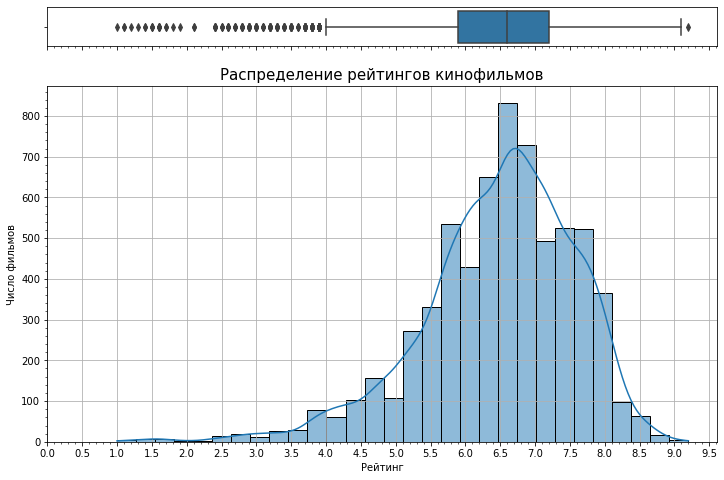

In [40]:
print(df['ratings'].describe(percentiles=[.25, .5, .75, .99]))

fig_rat, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': (.1, .9)}, figsize=(12, 8))
sns.boxplot(x=df['ratings'], ax=ax_box)
sns.histplot(x=df['ratings'], ax=ax_hist, bins=30, kde=True)
plt.title('Распределение рейтингов кинофильмов', fontsize=15)
ax_box.set(xlabel='')
ax_hist.set(xlabel='Рейтинг', ylabel='Число фильмов')
plt.minorticks_on()
plt.xticks(np.arange(0, 10, 0.5))
plt.grid()

Гистограмма рейтинга имеет вид нормального распределения с левым хвостом и пиком в области 6,5 баллов, который совпадает с медианой. Сама же медиана практически совпадает со средним, стандартное отклонение минимально, в общем данные выглядят однородными и реалистичными. Диаграмма размаха отсекает в качестве выбросов оценки ниже 4 и единичные оценки выше 9 баллов. Максимальный рейтинг в 9,2 балла не выглядит подозрительно, нет смысла дополнительно проверять эти записи. Рейтинги около 4 баллов, как мы знаем из практики, тоже реально существующее явление, да и количество таких картин на гистограмме довольно велико. Зато на диаграмме размаха бросается в глаза разрыв между выбросами в районе 2,5 баллов, начиная с этой отметки резко снижается и количество таких фильмов, что, впрочем, выглядит закономерно - фильмов с таким мусорным рейтингом и не должно быть много. В целом, сложно заподозрить имеющиеся данные в некорректности, но на всякий случай найдет количество таких картин, а также выведем несколько случайных фильмов из этой выборки, чтобы проверить данные по рейтингу в открытых источниках.

In [41]:
print('Количество фильмов с рейтингом менее 2.5 баллов:', df.query('ratings < 2.5').shape[0])
df.query('ratings < 2.5')[['title', 'type', 'production_country', 'director', 'genres', 'age_restriction', 'ratings', 'show_start_date']].sample(3)

Количество фильмов с рейтингом менее 2.5 баллов: 27


,title,type,production_country,director,genres,age_restriction,ratings,show_start_date
1226,Зомби каникулы,Художественный,Россия,К.Кемниц,"ужасы,триллер,комедия",18+,1.50,2013-03-29 12:00:00+00:00
1941,Что творят мужчины 2,Художественный,Россия,С.Андреасян,комедия,18+,2.10,2014-12-02 12:00:00+00:00
1468,Черная роза,Художественный,Россия,А.Невский,"детектив,триллер,криминал",16+,1.50,2014-04-16 12:00:00+00:00


Количество фильмов с подозрительно низким рейтингом крайне мало, а выборочная провека показала корректность данных об их рейтинге. Имеющиеся данные полностью пригодны для дальнейшего анализа.

Анализ параметра box_office, как ключевого для данного исследования, выполнен в рамках исследовательского анализа и приведен ниже в 3 разделе.

### Добавление новых столбцов

Для дальнейшего анализа нам понадобится выделить более конкретную информацию из некоторых колонок. Во-первых, создадим столбец с информацией о годе проката, выделив его из даты премьеры фильма.

In [42]:
df['show_start_year'] = pd.DatetimeIndex(df['show_start_date']).year

Далее создадим еще два столбца: с именем и фамилией главного режиссёра и основным жанром фильма. В столбцы войдут первые значения из списка режиссёров и жанров соответственно. Для этого создадим функцию sep_word, которая принимает на вход строку, разделяет, используя запятую в качестве разделителя, преобразуя ее в список, и возвращает первый элемент из этого списка.

In [43]:
def sep_word(string):
    return string.split(',')[0]

Для работы функции заменим пропущенные значения строкой 'None' и применим её к колонкам director и genres, поместив новые столбцы после исходных.

In [44]:
df['director'].fillna('None', inplace=True)
df.insert(7, 'main_director', df['director'].apply(sep_word))
df['genres'].fillna('None', inplace=True)
df.insert(16, 'main_genre', df['genres'].apply(sep_word))

Помня о имевшейся проблеме с пробелами в колонке с фамилиями режиссеров, применим аналогичный метод с проверкой количества до и после удаления пробелов вокруг строки.

In [45]:
print(len(df['main_director'].unique()))
df['main_director'] = df['main_director'].str.strip()
len(df['main_director'].unique())

4585


4585

Неявных дублей нет.

Также посчитаем, какую долю от общего бюджета фильма составляет государственная поддержка, поместив этот показатель в поле **budget_support_ratio**. Напишем функцию support_ratio, которая применяясь к строке возвращает процент государственного финансирования от общего бюджета, округленный до двух знаков. Т.к. при проверке количественных значений было обнаружено 17 фильмов с нулевым бюджетом, у таких картин функция возвращает NaN.

In [46]:
def support_ratio(row):
    if row['budget'] == 0:
        return np.nan
    return round((row['refundable_support'] + row['nonrefundable_support']) / row['budget'] * 100, 2)

df.insert(13, 'budget_support_ratio', df.apply(support_ratio, axis=1))

## Исследовательский анализ данных

Создадим сводную таблицу, которая будет содержать информацию о количестве фильмов с указанной информацией о прокате, общем количеством фильмов и долю фильмов с указанной информацией о сборах за каждый год. Также рассчитаем долю фильмов с указанной информацией о прокате за весь изучаемый период, а для наглядности построим столбчатый график, который будет визуализировать общее количество фильмов и количество фильмов с информацией о прокате за каждый год.

Доля фильмов с указанной информацией о прокате в кинотеатрах за изучаемый период: 42.15 %


,w/box_office_movies,movies_count,w/box_office_movies_part
show_start_year,,,
2010,105,984,10.67
2011,109,621,17.55
2012,127,591,21.49
2013,184,629,29.25
2014,278,806,34.49
2015,460,697,66.00
2016,523,813,64.33
2017,356,503,70.78
2018,474,888,53.38


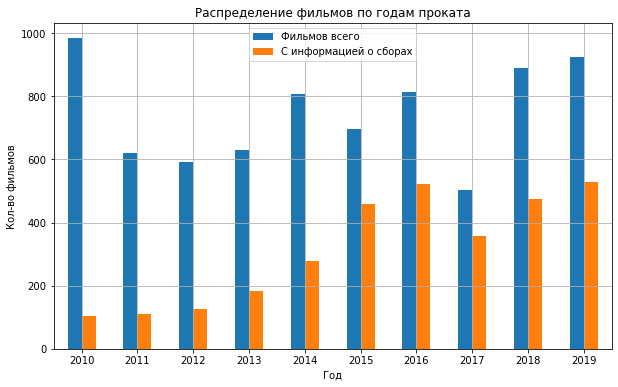

In [47]:
print('Доля фильмов с указанной информацией о прокате в кинотеатрах за изучаемый период:', 
      round(df[df['box_office'].isna() == False].shape[0] / df.shape[0] * 100, 2),'%')

movies_count_per_year = df.pivot_table(index='show_start_year', values=['pu_number', 'box_office'], aggfunc='count')
# расчет доли фильмов с информацией о сборах
movies_count_per_year['w/box_office_movies_part'] = (
    movies_count_per_year['box_office'] / movies_count_per_year['pu_number'] * 100).round(2)
movies_count_per_year.rename(columns={'box_office': 'w/box_office_movies', 'pu_number': 'movies_count'}, inplace = True)
display(movies_count_per_year)

df.groupby('show_start_year')[['pu_number', 'box_office']].count().plot(
    kind='bar', title='Распределение фильмов по годам проката', xlabel='Год', ylabel='Кол-во фильмов', grid=True, figsize=(10, 6))
plt.legend(['Фильмов всего', 'С информацией о сборах'])
plt.xticks(rotation = 'horizontal')
plt.show()

Количество фильмов выходящих в прокат не имеет четкой динамики. Максимальное их количество вышло в первый год наблюдений, затем резко упало, и разнонаправленно менялось в дальнейшем, однако к концу периода их количество практически восстановилось. При этом динамика количества картин с указанной информацией о сборах более четкая. До 2016 года наблюдался уверенный рост как количества, так и доли таких фильмов, относительного общего числа. В 2017 году произошел резкий провал количества выпущенных фильмов, с одновременным снижением числа фильмов с информацией о сборах, однако это снижение было не таким резким, что в совокупности вылилось в максимальную за наблюдаемый период долю фильмов с указанной информацией о прокате в кинотеатрах: более 70%. Далее произошел резкий восстановительный рост общего количества фильмов, а рост числа фильмов имеющих информацию о сборах оказался более плавным, соответственно их доля откатилась на показатели ниже 2015 года - не многим более каждого второго фильма. Для наглядности построим график изменения доли фильмов с информацией о прокате.

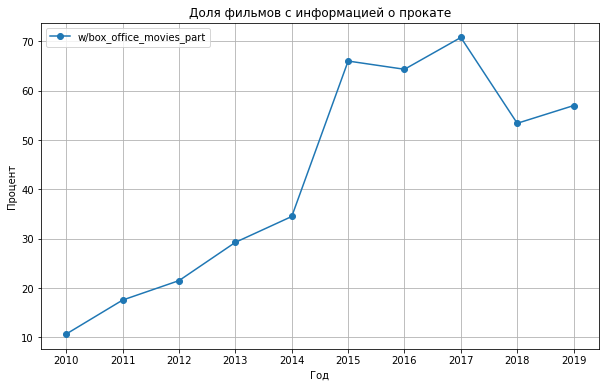

In [48]:
movies_count_per_year.plot(y='w/box_office_movies_part', title='Доля фильмов с информацией о прокате',
                           xlabel='Год', ylabel='Процент', style='o-', grid=True, figsize=(10, 6))
plt.xticks(range(2010, 2020, 1))
plt.show()

Изучим, как менялась динамика проката по годам. В каком году сумма сборов была минимальной? А максимальной? Для этого создадим сводную таблицу, которая содержит информацию о прокате фильмов в динамике по годам: количество фильмов с имеющейся информацией о сборах, среднее, медиану и общую сумму сборов в миллионах рублей по соответсвующему году. На основе полученной сводной таблицы построим график, отражающий общую сумму сборов по годам.

,count,mean,median,sum_mln
show_start_year,,,,
2010,105,23130.00,1700.00,2.43
2011,109,129383.00,3000.00,14.10
2012,127,54753.00,5760.00,6.95
2013,184,161955.00,3522.00,29.80
2014,278,26780387.00,18885.00,7444.95
2015,460,84708841.00,5003450.00,38966.07
2016,523,91516108.00,4000811.00,47862.92
2017,356,136414801.00,10177834.00,48563.67
2018,474,104782312.00,8911534.00,49666.82


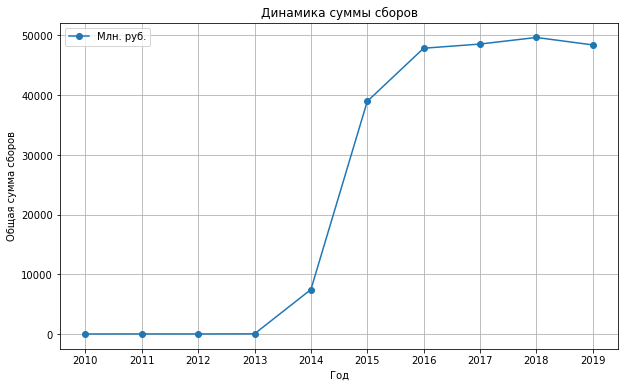

In [49]:
box_office_stat = df.pivot_table(
    index='show_start_year', values='box_office', aggfunc=['count', 'mean', 'median', 'sum']).round()
box_office_stat.columns = ['count', 'mean', 'median', 'sum_mln']
box_office_stat['sum_mln'] = box_office_stat['sum_mln'] / 1000000
display(box_office_stat)

box_office_stat.plot(y='sum_mln', style='o-', title='Динамика суммы сборов',
                     xlabel='Год', ylabel='Общая сумма сборов', grid=True, figsize=(10, 6))
plt.legend(['Млн. руб.'])
plt.xticks(range(2010, 2020, 1))
plt.show()

По графику хорошо заметен взрывной рост суммы сборов в период 2013-2016 годов. За 3 года произошел рост в 1600 раз, при этом львиную часть этого роста обеспечил 2015 год. Далее идет медленный рост с несущественным сокращением к последнему году наблюдений. Наблюдаемую картину можно частично объяснить увеличением количества картин, по которым рассчитывается общая сумма сборов, однако их число увеличилось менее чем в 3 раза, а сумма сборов более чем в 1,5 тысячи раз. К тому же, в 2017 количество картин ощутимо снизилось, а сумма сборов наоборот выросла. Значит количество фильмов это лишь второстепенный фактор, оказавший незначительное влияние на такое увеличение суммы сборов. Скорее всего мы обладаем неполными данными по сборам за этот период.

С помощью сводной таблицы посчитаем среднюю и медианную сумму сборов для каждого года.

In [50]:
box_office_stat.insert(3, 'mean/median_ratio', round(box_office_stat['mean']/box_office_stat['median'], 3))
box_office_stat

,count,mean,median,mean/median_ratio,sum_mln
show_start_year,,,,,
2010,105,23130.00,1700.00,13.61,2.43
2011,109,129383.00,3000.00,43.13,14.10
2012,127,54753.00,5760.00,9.51,6.95
2013,184,161955.00,3522.00,45.98,29.80
2014,278,26780387.00,18885.00,1418.08,7444.95
2015,460,84708841.00,5003450.00,16.93,38966.07
2016,523,91516108.00,4000811.00,22.87,47862.92
2017,356,136414801.00,10177834.00,13.40,48563.67
2018,474,104782312.00,8911534.00,11.76,49666.82


По построенной выше сводной таблице хорошо видно, что рост происходит за счет увеличения сборов каждым фильмом. При этом на себя обращает внимание колоссальная разница между средним и медианным показателем ежегодных сборов, которая в 2014 году, когда начался период быстрого роста, составила близкие к интенсивности общего роста, 1,5 тысячи раз. Очевидно, что такая разница должна быть вызвана значительной неоднородностью показателя сборов у разных фильмов.

In [51]:
df['box_office'].describe(percentiles=[.25, .5, .75, .99])

count         3143.00
mean      76671582.27
std      240738045.10
min              0.00
25%          87802.50
50%        2351960.00
75%       24138966.22
99%     1284025459.81
max     3073568690.79
Name: box_office, dtype: float64

Для визуальной оценки распределения количества фильмов по сборам построим гистограмму по ограниченному округленнием в большую сторону показателю средних сборов набору данных (100 миллионов рублей). Учитывая огромную разницу между границами параметров описательной статистики, построим внутри основной диаграммы дополнительную, показывающую тот же параметр, но ограниченный округленным (до 100 тысяч) 25% квартилем. Также для более наглядного определения границ диапазона наиболее типовых, нормальных значений, построим диаграмму размаха и оценим разброс значений параметра, после чего рассчитаем количество фильмов, сборы которых выходят за границу нормальных значений.

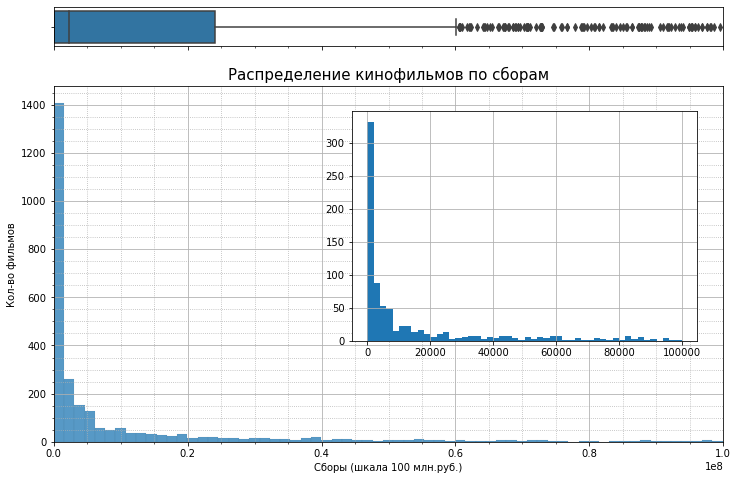

In [52]:
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': (.1, .9)}, figsize=(12, 8))
sns.boxplot(x=df['box_office'], ax=ax_box)
sns.histplot(x=df['box_office'], bins=2000, ax=ax_hist)
plt.title('Распределение кинофильмов по сборам', fontsize=15)
ax_box.set(xlabel='')
ax_hist.set(xlabel='Сборы (шкала 100 млн.руб.)', ylabel='Кол-во фильмов')
ax_hist.set_xlim(0, 100000000)
plt.minorticks_on()
plt.grid(which='major')
plt.grid(which='minor', linestyle=':')
plt.axes([.47, .3, .4, .4])
plt.hist(df['box_office'], bins=50, range=(0, 100000))
plt.grid(which='major')

In [53]:
print('Количество фильмов, сумму сборов которых можно отнести к выбросам:', df.query('box_office >= 60000000').shape[0])
print('Доля таких фильмов от общего количества картин с информацией о сборах:', round(
    df.query('box_office >= 60000000').shape[0] / df.query('box_office == box_office').shape[0], 3), '%')

Количество фильмов, сумму сборов которых можно отнести к выбросам: 548
Доля таких фильмов от общего количества картин с информацией о сборах: 0.174 %


Статистически, нижняя граница нормальных значения ограничена нулем, за верхнюю можно принять показатель 60 миллионов. Количество таких фильмов крайне невелико - менее двух десятых процента от общего количества, однако вероятно именно они оказали такое влияние на рост общей суммы сборов с 2013 года. Чтобы убедиться в этом найдем количество таких фильмов за каждый год.

In [54]:
df.query('box_office >= 60000000').groupby('show_start_year')['pu_number'].count()

show_start_year
2014     20
2015    100
2016    111
2017     93
2018    119
2019    105
Name: pu_number, dtype: int64

Действительно, в 2013 году таких фильмов не было вообще, а начиная с 2015, когда график резко пошел вверх, из количество увеличиилось примерно в 5 раз по сравнению с 2014 и постоянно держится на уровне 100 картин в год.

Далее определим, влияет ли возрастное ограничение аудитории («6+», «12+», «16+», «18+» и т. д.) на сборы фильма в прокате в период с 2015 по 2019 год? Посмотрим, фильмы с каким возрастным ограничением собрали больше всего денег в прокате и будет ли меняеться картина в зависимости от года? 

Для начала сгруппируем данные по возрастным категориям и рассчитаем общую сумму сборов в миллионах рублей за рассматриваемый период

In [55]:
round(df.query('show_start_year >= 2015').groupby('age_restriction')['box_office'].sum() / 1000000, 2)

age_restriction
0+      809.08
6+    55269.51
12+   60619.41
16+   76029.25
18+   40753.31
Name: box_office, dtype: float64

Самая коммерчески успешная категория - картины с рейтингом 16+. При этом обращает на себя внимание сумма сборов у группы с рейтингом 0+, она в десятки раз меньше, чем у любого другого, и почти на два порядка меньше лидера рейтинга. Стоит выяснить, насколько эту разницу можно объяснить числом фильмов с соответсвующим возрастным ограничением. Помня о крайне высокой разнородности данных по сборам, рассчитаем не только среднюю, но и медианную сумму сборов в миллионах рублей с группировкой по возрастным категориям за период с 2015 года.

In [56]:
age_restriction_stat = df.query('show_start_year >= 2015').pivot_table(
    index='age_restriction', values='box_office', aggfunc=['count', 'mean', 'median'])
age_restriction_stat.columns = ['movies_count', 'mean_box_office', 'median_box_office']
age_restriction_stat['mean_box_office'] = age_restriction_stat['mean_box_office'] / 1000000
age_restriction_stat['median_box_office'] = age_restriction_stat['median_box_office'] / 1000000
age_restriction_stat

,movies_count,mean_box_office,median_box_office
age_restriction,,,
0+,91,8.89,2.94
6+,314,176.02,14.10
12+,347,174.70,5.18
16+,800,95.04,5.67
18+,788,51.72,6.26


При анализе средней суммы сборов картина немного меняется. Абсолютным аутсайдером по прежнему является категория 0+, однако привлекает внимание изменившийся расклад в иных категориях. Самыми коммерчески успешными становятся категории 6+ и 12+. Их суммарные сборы не сильно уступают картинам более высоких возрастных категорий, однако их количество ощутимо меньше, что в итоге дает гораздо более высокие сборы в пересчете на один фильм. Вероятно это объясняется паттерном потребительского поведения их возрастной категории - это детские/семейные фильмы, которые смотрят всей семьей, и не редко более одного раза, что дает высокий зрительский поток, в отличие от фильмы более высоких возрастных категорий. И если низкие результаты категории 0+ были предсказуемы, то плохие результаты категории 18+ были не очевидны. Количество таких фильмов практически не уступает наиболее популярному рейтингу (16+), а общие сборы почти в 2 раза меньше, что в итоге делает данную категорию наименее коммерчески успешной после категории 0+. 

При изучении медианных сборов детали существенно меняются: категория 0+ остается аутсайдером, а категория 6+ лидером. Однако граница между остальными возрастными категориями практически размывается, они становятся очень близки, а разрыв между любой категорией заметно сократился. В дальнейшем для исследования влияния категориальных переменных на сумму сборов целесообразно использовать именно медиану.

Посмотрим меняется ли картина в зависимости от года. Создадим для этого сводную таблицу, показывающую медианные и общие сборы по возрастным категориям за каждый год, а также построим простой линейный график с динамикой сборов по возрастным группам.

sum                                               median  \
age_restriction     0+       6+      12+      16+      18+     total     0+   
show_start_year                                                               
2015            379.05  8172.73 13616.08 11367.32  5430.88  38966.07   2.94   
2016            150.23 12053.15 12204.45 16664.47  6790.64  47862.92   2.57   
2017            229.60 12086.14  7851.39 18745.04  9651.50  48563.67  22.18   
2018             32.45 10104.97 14267.29 16503.60  8758.50  49666.82   3.62   
2019             17.75 12852.51 12680.20 12748.82 10121.80  48421.07   3.89   
total           809.08 55269.51 60619.41 76029.25 40753.31 233480.55   2.94   

                                             
age_restriction    6+   12+  16+  18+ total  
show_start_year                              
2015            20.38 15.35 4.88 4.65  5.00  
2016             3.03  4.69 5.18 6.38  4.00  
2017            51.99 13.22 9.70 8.21 10.18  
2018            14.69  8.93 9.01 7.60  8.91  
2019            14.20  3.41 3.21 5.60  4.73  
total           14.10  5.18 5.67 6.26  5.96

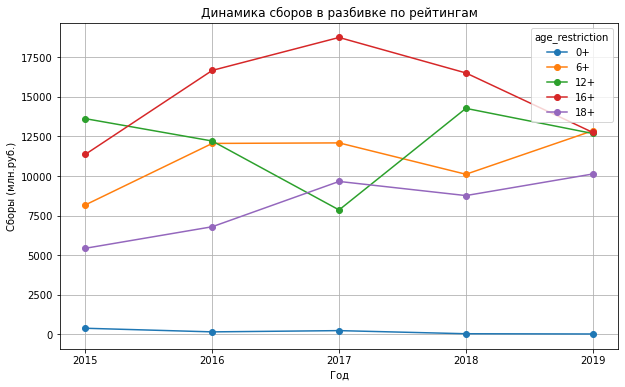

In [86]:
age_restriction_pivot_table = df.query('show_start_year >= 2015').pivot_table(
    index='show_start_year', columns='age_restriction', values='box_office', margins=True, margins_name='total', 
    aggfunc=['sum', 'median']) / 1000000
display(age_restriction_pivot_table)
(df.query('show_start_year >= 2015').pivot_table(
    index='show_start_year', columns='age_restriction', values='box_office', aggfunc='sum') / 1000000).plot(
    title='Динамика сборов в разбивке по рейтингам', xlabel='Год', ylabel='Сборы (млн.руб.)', style='o-', grid=True, figsize=(10, 6))
plt.xticks(range(2015, 2020, 1))
plt.show()

- категория 0+ показывает значительное и устойчивое снижение сборов, вызванное снижением количества выпускаемых в прокат фильмов, при этом медианные сборы не имеют четкой тенденции на изменение, показатели на начало и конец периода не отличаются, при этом стоит отметить аномальный 2017 год - медианные сборы в этом году выросли более чем в 7 раз, даже обогнав все иные категории, кроме доминирующей весь период 6+, что может говорить о выходе в этом году в прокат ряда фильмов, имевших нетипичный коммерческий успех для данного возрастного ограничения;
- категория 6+ показывает устойчивую тенденцию к росту по сумме, однако медианный показатель за рассматриваемый период в начале резко упал, далее скачкообразно вырос, а потом откатился на величину, меньшую стартовой, и держится на этом уровне последние три года;
- категория 12+ является единственной, показавшей по итогам общее снижение сборов, при этом медианные сборы также значительно снизились, и что характерно, это единственная категория, имеющая максимальный показатель медианных сборов не в 2017 году;
- категория 16+ являясь самой коммерчески успешной, показала минимальный рост за период, при этом, он был нелинейным - за первые два года наблюдался значительный рост, однако за последующие два года показатель практически вернулся на исходную точку, медианные сборы в целом повторяют эту картину;
- категория 18+ показывает устойчивую тенденцию к росту, с единственным минимальным снижением в 2018 году, средние сборы, в целом, также показывают тенденции к росту.

В целом, динамика сборов разных групп имеет разнонаправленный характер, но по итогам последнего (2019) года сборы практически всех основных категорий (кроме 0+) сошлись в одной точке, только фильмы 18+ отстают по сумме на 25%. Отдельно стоит выделить 2017 год - он является рекордным по медианным сборам сразу для всех возрастных категорий, кроме 12+. Вероятнее всего это связано с минимальным количеством фильмов, что при сохранении аналогичного прочим периодам зрительского потока дало наиболее количество просмотров каждого фильма. Проверим эту гипотезу.

In [58]:
df.query('show_start_year >= 2015 and box_office == box_office').groupby('show_start_year')['pu_number'].count()

show_start_year
2015    460
2016    523
2017    356
2018    474
2019    527
Name: pu_number, dtype: int64

Гипотеза подтвердилась, рекордные показатели средних сборов вызваны именно минимальным количеством фильмов за изучаемый период.

## Исследование фильмов, которые получили государственную поддержку

Перед началом исследования посмотрим какой процент фильмов вообще получал государтвенную поддержку. Т.к. такая поддержка подразумевает выделение её только фильмам с российским участием, будем считать процент от фильмов, имеющих Россию в списке страны-производителя. Заодно и проверим, нет ли не российских фильмов, получавших государственное финансирование. 
К тому же, из преобработки данных мы знаем, что страна производства не заполнена у двух фильмов, посмотрим на них.

In [59]:
print(df.query('(refundable_support == refundable_support and refundable_support != 0) or (nonrefundable_support == nonrefundable_support and nonrefundable_support != 0)')['production_country'].unique())
df[df['production_country'].isna() == True]

['Россия' 'Россия, Франция, Латвия' 'Россия-Украина' 'Россия, Италия'
 'Россия, Украина, Польша' 'Россия, Германия, Великобритания'
 'Россия, Германия' 'Россия, Армения' 'Россия-Словакия-Чехия'
 'Россия, Латвия, Чешская Республика'
 'Россия, Германия, Казахстан, Польша, Китай' 'Россия, Сербия'
 'Россия - Грузия' 'Россия-Китай' 'Россия, Бельгия, Финляндия']


,title,pu_number,show_start_date,type,film_studio,production_country,director,main_director,producer,age_restriction,refundable_support,nonrefundable_support,budget,budget_support_ratio,financing_source,ratings,genres,main_genre,box_office,show_start_year
3186,"Детский юмористический киножурнал ""Ералаш. Ну ...",111001216,2016-02-09 12:00:00+00:00,Художественный,"ООО ""Продюсерский центр ЕРАЛАШ""",NaN,"Р.Светлов, И.Магитон, А.Арутюнян, Л.Мирский, А...",Р.Светлов,"ООО ""Продюсерский центр ЕРАЛАШ""",0+,NaN,NaN,NaN,NaN,NaN,7.20,"детский,комедия",детский,194527.00,2016
4441,Мульт личности. Выпуск 5,214000410,2010-01-25 12:00:00+00:00,Художественный,NaN,NaN,None,None,NaN,0+,NaN,NaN,NaN,NaN,NaN,4.00,"мультфильм,комедия",мультфильм,NaN,2010


Для Ералаша установим страну производтва "Россия". Для "Мульт личности. Выпуск 5" отсутствует какая-либо информация, позволяющая достоверно установить страну, однако поиск в открытых источниках позволяет идентифицировать ее как Россию. Заменим оба пропущенных значения на Россию, после чего осуществим рассчет.

In [60]:
df['production_country'].fillna('Россия', inplace=True)
print('Процент фильмов, получавших государственное финансирование:',
      round(df.query('(refundable_support == refundable_support and refundable_support != 0) or (nonrefundable_support == nonrefundable_support and nonrefundable_support != 0)').shape[0] /
            df[df['production_country'].str.contains('Россия', regex=False)].shape[0] * 100, 2), '%')

Процент фильмов, получавших государственное финансирование: 16.78 %


Для удобства дальнейшей работы создадим переменную support_data, содержащую выборку фильмов, которую будем в дальнейшем постоянно использовать в анализе картин, получивших государственную поддержку. Это фильмы, для которых известна информация об общем бюджете и кассовых сборах, при этом она не равна нулю.

In [61]:
support_data = df.query('budget > 0 and box_office > 0')

Для первичного анализа создадим таблицу, которая будет содержать следующую информацию с разбивкой по годам:
- о количестве фильмов, получивших поддержку (movies_count);
- их общем бюджете (budget) в миллионах рублей;
- доля государственной поддержки от общего бюджета в процентах (budget_support_ratio);
- суммарном объеме поддержки (total_support) в миллионах рублей;
- объёме возвратных средств государственной поддержки (refundable_support) в миллионах рублей;
- объём невозвратных средств государственной поддержки (nonrefundable_support) в миллионах рублей;
- сборах в миллионах рублей (box_office);
- окупаемости фильмов в процентах (payback);
- среднем рейтинге фильмов (mean_ratings).

In [62]:
support_stat = support_data.groupby('show_start_year')[['budget', 'refundable_support', 'nonrefundable_support', 'box_office',
                                                       'pu_number', 'budget_support_ratio', 'ratings']].agg(
{'budget':'sum',
'refundable_support':'sum',
'nonrefundable_support':'sum',
'box_office':'sum',
'pu_number':'count',
'budget_support_ratio':'mean',
'ratings':'mean'})
support_stat[['budget', 'refundable_support', 'nonrefundable_support', 'box_office']] = support_stat[
    ['budget', 'refundable_support', 'nonrefundable_support', 'box_office']] / 1000000
support_stat['total_support'] = support_stat['refundable_support']+support_stat['nonrefundable_support']
support_stat['payback'] = support_stat['box_office'] / support_stat['total_support'] * 100
support_stat = support_stat.reindex(
    columns=['pu_number', 'budget', 'budget_support_ratio', 'total_support', 'refundable_support', 'nonrefundable_support',
             'box_office', 'payback', 'ratings'])
support_stat.rename(columns={'pu_number': 'movies_count', 'budget_support_ratio': 'budget_support_ratio',
                             'ratings': 'avg_ratings'}, inplace=True) 
support_stat

,movies_count,budget,budget_support_ratio,total_support,refundable_support,nonrefundable_support,box_office,payback,avg_ratings
show_start_year,,,,,,,,,
2013,2,255.44,47.32,134.35,0.00,134.35,20.32,15.13,6.70
2014,15,1279.48,52.14,549.00,71.00,478.00,1007.19,183.46,5.96
2015,77,7213.21,53.45,3187.54,547.15,2640.39,4814.61,151.04,6.06
2016,57,7210.24,55.16,3965.64,902.50,3063.14,4957.72,125.02,5.67
2017,37,6866.57,48.73,3063.97,674.35,2389.62,10759.52,351.16,6.05
2018,52,6651.69,50.99,3098.00,592.00,2506.00,9517.66,307.22,6.04
2019,59,11055.07,49.25,3906.00,728.00,3178.00,8262.02,211.52,6.23


При первичном изучении таблицы на себя обращает внимание стартовый 2013 год. Во-первых, малым количеством фильмов, во-вторых, их крайне провальным прокатом, и в-третьих, тем, что это единственный год за изучаемый период, когда предоставлялась исключительно невозвратная поддержка. При этом, средний рейтинг в 2013 году является максимальным за весь период, что ставит под сомнение версию о низком качестве, как причине кассового провала этих фильмов.

Основная наблюдаемая тенденция - резкий рост количества картин получивших поддержку в начале периода (за первые два года), соответственно растет как общий бюджет таких картин, так суммы государственного софинансирования. Однако доля государственной поддержки от общего бюджета остается на одном уровне с незначительными колебаниями, в пределах 10% от среднего значения.

Из-за резкого роста количества фильмов соответствующим образом растет и суммарный бюджет, равно как и сумма государтвенной поддежки. Для изучения как менялся в динамике средний размер затрат на поддежку одной картины построим график с разбивкой по видам финансирования.

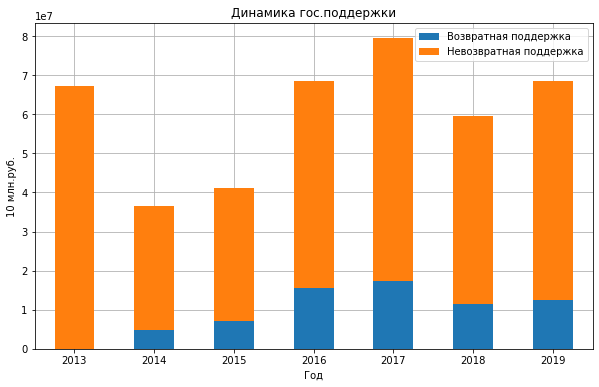

In [63]:
df.query('budget == budget and budget != 0').groupby(
    'show_start_year')[['refundable_support', 'nonrefundable_support']].mean().plot(
    kind='bar', title='Динамика гос.поддержки', xlabel='Год', ylabel='10 млн.руб.', figsize=(10, 6), grid=True, zorder=2, stacked=True)
plt.legend(['Возвратная поддержка', 'Невозвратная поддержка'])
plt.xticks(rotation=0)
plt.show()

Мы видим, что максимальный размер невозвратной поддержки пришелся на первый, наиболее провальный с точки зрения окупаемости год. В последующие два года происходит резкое снижение среднего размера государственной поддержки, вероятно связанное с провалом 2013 года, однако к 2016 году ее размер восстанавливается, но только с учетом возвратных средств. В последующем, до конца периода, средняя сумма поддержки стабилизирутся с периодическими колебаниями.

Перед тем как переходить к анализу влияния конкретных факторов на окупаемость фильмов, получавших государственную поддержку, посмотри на корреляцию между сборами и объемом такой поддержки. Для этого добавим колонку с суммарным объемом поддержки, затем рассчитаем коэффициент и построим точечный график.

Коэффициент корреляции между сборами и размером совокупного государственного финансирования: 0.481


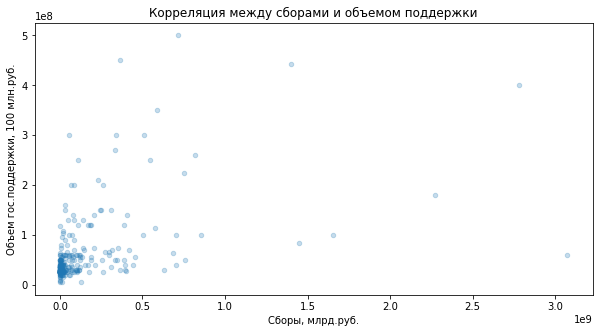

In [64]:
support_data = support_data.assign(total_support = support_data['refundable_support'] + support_data['nonrefundable_support'])
print('Коэффициент корреляции между сборами и размером совокупного государственного финансирования:',
      support_data['box_office'].corr(support_data['total_support']).round(3))
support_data.plot(x='box_office', y='total_support', kind='scatter', title='Корреляция между сборами и объемом поддержки',
                  xlabel='Сборы, млрд.руб.', ylabel='Объем гос.поддержки, 100 млн.руб.', figsize=(10, 5), alpha=0.25)
plt.show()

Коэффициент имеет пограничное значение, которое не позволяет заявить о четкой взаимосвязи этих величин. График также не показывает какой-либо выраженной взаимосвязи. Значит государственная поддержка не оказывает прямого влияния на сборы фильмов, на них влияют другие факторы. Сравним фильмы получавшие поддержку и нет по основным критериям - средние рейтинг, сборы и окупаемость.

In [65]:
print('Средний рейтинг фильмов с российским участием:', 
      round(df[df['production_country'].str.contains('Россия', regex=False)]['ratings'].mean(), 2))
print('Средний рейтинг фильмов получивших поддержку:', 
      round(df.query('(refundable_support == refundable_support and refundable_support != 0) or (nonrefundable_support == nonrefundable_support and nonrefundable_support != 0)')['ratings'].mean(), 2))
print('')
print('Средние сборы фильмов с российским участием в миллионах рублей:', 
      round(df[df['production_country'].str.contains('Россия', regex=False)]['box_office'].mean() / 1000000, 2))
print('Средние сборы фильмов получивших поддержку в миллионах рублей:', 
      round(df.query('(refundable_support == refundable_support and refundable_support != 0) or (nonrefundable_support == nonrefundable_support and nonrefundable_support != 0)')['box_office'].mean() / 1000000, 2))
print('')
print('Средняя окупаемость фильмов с российским участием:', 
      round(df[df['production_country'].str.contains('Россия', regex=False)]['box_office'].mean() / 
      df[df['production_country'].str.contains('Россия', regex=False)]['budget'].mean() * 100, 2), '%')
print('Средняя окупаемость фильмов получивших поддержку:',
      round(support_data['box_office'].mean() / support_data['budget'].mean() * 100, 2), '%')

Средний рейтинг фильмов с российским участием: 6.12
Средний рейтинг фильмов получивших поддержку: 6.0

Средние сборы фильмов с российским участием в миллионах рублей: 61.9
Средние сборы фильмов получивших поддержку в миллионах рублей: 133.27

Средняя окупаемость фильмов с российским участием: 48.42 %
Средняя окупаемость фильмов получивших поддержку: 97.06 %


In [66]:
df[df['production_country'].str.contains('Россия', regex=False)]

,title,pu_number,show_start_date,type,film_studio,production_country,director,main_director,producer,age_restriction,refundable_support,nonrefundable_support,budget,budget_support_ratio,financing_source,ratings,genres,main_genre,box_office,show_start_year
61,Американская дочь,111005515,2015-04-23 12:00:00+00:00,Художественный,"АО ""Караван"", Компания ""Америкен Дистрибьюшн"",...","Россия, Казахстан, США",К.Шахназаров,К.Шахназаров,NaN,6+,NaN,NaN,NaN,NaN,NaN,7.00,"драма,комедия",драма,300.00,2015
311,Фара,211040615,2015-09-10 12:00:00+00:00,Художественный,"ЗАО Студия ""Эй-Би-Эй"", Национальный продюсерск...",Россия - Казахстан,А.Карпыков,А.Карпыков,Б.Айрапетян,12+,NaN,NaN,NaN,NaN,NaN,7.60,"триллер,драма",триллер,NaN,2015
336,Каникулы строгого режима,111008514,2014-08-07 12:00:00+00:00,Художественный,"ООО ""Кинобазза"" по заказу ЗАО ""Дирекция Кино""",Россия,И.Зайцев,И.Зайцев,"А.Максимов, Н.Попов, Д.Файзиев",12+,NaN,NaN,NaN,NaN,NaN,7.10,"драма,комедия,приключения",драма,360.00,2014
462,Август. Восьмого,111000612,2012-02-07 12:00:00+00:00,Художественный,"ЗАО ""ПК ""ГЛАВКИНО""",Россия,Д.Файзиев,Д.Файзиев,"Д.Файзиев, Ф.Бондарчук, И.Бачурин",12+,NaN,NaN,NaN,NaN,NaN,6.10,"драма,военный",драма,6775.00,2012
463,Тот еще...!,111001612,2012-02-20 12:00:00+00:00,Художественный,"ООО ""Энджой мувиз""",Россия,С.Андреасян,С.Андреасян,Г.Малков,12+,NaN,NaN,NaN,NaN,NaN,2.60,"фэнтези,комедия,семейный",фэнтези,12779.00,2012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7476,Я свободен,111023019,2019-12-26 12:00:00+00:00,Художественный,"АО ""ТПО ""Киностудия им. М.Горького""",Россия,И.Северов,И.Северов,С.Зернов,12+,0.00,30000000.00,46154000.00,65.00,Министерство культуры,5.90,драма,драма,NaN,2019
7478,(Не)идеальный мужчина,111023119,2019-12-24 12:00:00+00:00,Художественный,"ООО ""Нон-Стоп Продакшн""",Россия,М.Бальчюнас (псевдоним М.Вайсберг),М.Бальчюнас (псевдоним М.Вайсберг),"С.Мелькумов, А.Роднянский, М.Вайсберг, Р.Минас...",12+,40000000.00,60000000.00,150147502.00,66.60,Фонд кино,4.50,"комедия,фантастика,мелодрама",комедия,NaN,2019
7479,Эколав,111023219,2019-12-26 12:00:00+00:00,Художественный,ВГИК,Россия,Д.Григорьев,Д.Григорьев,ВГИК,18+,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,2019
7484,"Машины песенки. Серия ""Испанские мотивы""",124010619,2019-12-30 12:00:00+00:00,Анимационный,"Анимаккорд Лтд., ООО Студия ""АНИМАККОРД""","Республика Кипр, Россия",А.Беляев,А.Беляев,Д.Ловейко,0+,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,2019


Рейтинг у двух групп фильмов практически одинаковый, а вот средние сборы и окупаемость у фильмов, получавших финансирование, вдвое выше.

Подробнее изучим окупаемость фильмов, получающих поддержку. И начнем с изучения влияния жанра на окупаемость. Построим парный график, левая часть которого показывает, какой процент от производственного бюджета заработали картины каждого жанра (красным пунктиром выделена граница окупаемости), а правая - общую сумму выделенных средств государственной поддержки по жанрам.

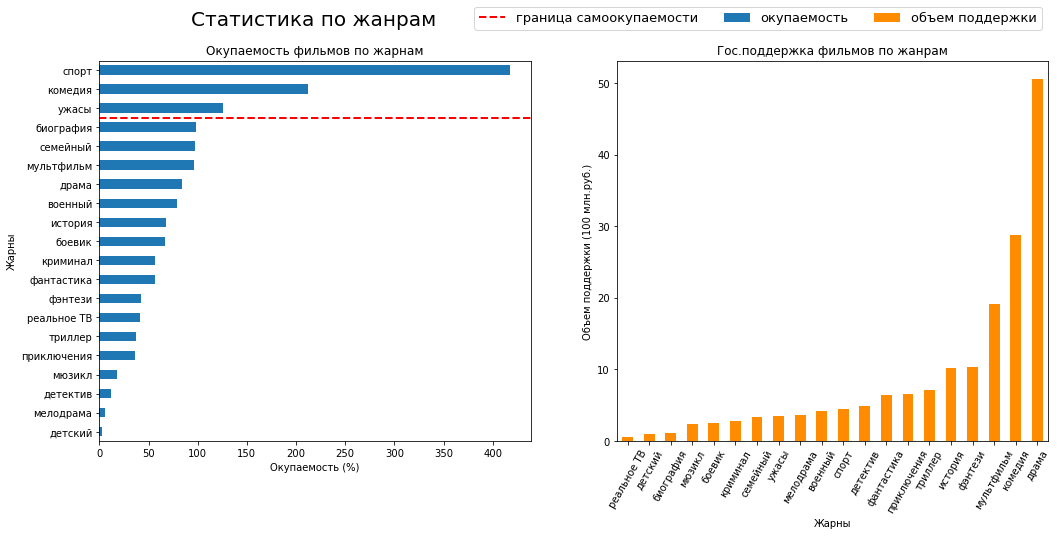

In [84]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(17, 7), gridspec_kw={'width_ratios': (.5, .5)})
plt.suptitle('Статистика по жанрам', fontsize=20, x=0.3)

payback_genre_grouped = support_data.query('main_genre != "None"').groupby('main_genre')[['budget', 'box_office']].sum()
payback_genre_grouped['payback'] = payback_genre_grouped['box_office'] / payback_genre_grouped['budget'] * 100
payback_genre_grouped['payback'].sort_values(ascending=True).plot(kind='barh', ax=axs[0])
axs[0].set(title='Окупаемость фильмов по жарнам', xlabel='Окупаемость (%)', ylabel='Жарны')
payback_zero_line = payback_genre_grouped[payback_genre_grouped.payback < 100]
axs[0].axhline(y=len(payback_zero_line)-0.5, color='r', label='self-repayment', linestyle='--', linewidth=2)

support_genre_grouped = support_data.query('main_genre != "None"').groupby(
    'main_genre')[['budget', 'refundable_support', 'nonrefundable_support', 'box_office']].sum()
support_genre_grouped['total_support'] = support_genre_grouped[
    'refundable_support'] + support_genre_grouped['nonrefundable_support']
support_genre_grouped = support_genre_grouped / 100000000
support_genre_grouped['total_support'].sort_values().plot(kind='bar', color='DarkOrange', ax=axs[1])
axs[1].set(title='Гос.поддержка фильмов по жанрам', xlabel='Жарны', ylabel='Объем поддержки (100 млн.руб.)')
plt.xticks(rotation=60)
legendEntries = ('граница самоокупаемости', 'окупаемость', 'объем поддержки')
fig.legend(legendEntries, ncol=len(legendEntries), fontsize=13, loc='upper right', bbox_to_anchor=(0.9, 1))
plt.show()

In [68]:
len(support_data.query('main_genre != "None"')['main_genre'].unique())

20

Коммерчески успешными можно признать лишь три жанра из двух десятков. Причем два из них не входят даже в пятерку жанров по объему поддержки. Единственный жанр, у которого объем поддержки коррелирует с его окупаемостью - это коммедии. Драмы же, несмотря на рекордную поддержку, не могут окупить затраты на производство. Однако окупаемость напрямую зависит от размера бюджета, поэтому дополнительно оценим как соотносится объем поддержки с коммерческими сборами различных жанров.

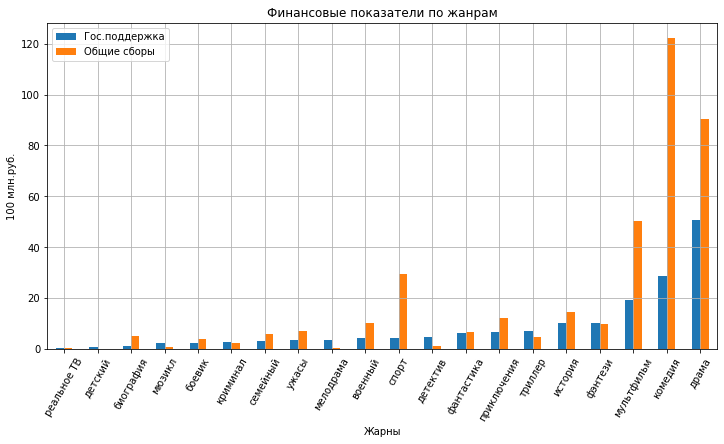

In [69]:
support_genre_grouped[['total_support', 'box_office']].sort_values(by='total_support').plot(
    kind='bar', title='Финансовые показатели по жанрам', xlabel='Жарны', ylabel='100 млн.руб.', figsize=(12, 6), grid=True)
plt.legend(['Гос.поддержка', 'Общие сборы'])
plt.xticks(rotation=60)
plt.show()

In [70]:
support_genre_grouped.query('box_office < total_support').index

Index(['детектив', 'детский', 'криминал', 'мелодрама', 'мюзикл', 'реальное ТВ',
       'триллер', 'фэнтези'],
      dtype='object', name='main_genre')

Девять жанров, а это почти половина, не могут окупить не то, чтобы собственный бюджет, а даже размер выданной поддержки. У хорошо окупающихся комедийных и спортивных фильмов ожидаемо наблюдается значительное превышение сборов над выделенной поддержкой, особенно впечатляюще выгдят спортивные фильмы. Посмотрим какой средний рейтинг получают агрегированные по жанрам фильмы c привязкой к сборам и окупаемости.

In [71]:
support_genre_grouped['payback'] = support_genre_grouped['box_office'] / support_genre_grouped['budget'] * 100
support_genre_grouped = support_genre_grouped.merge(support_data.query('main_genre != "None"').groupby(
    'main_genre')[['ratings', 'pu_number']].agg({'ratings':'mean', 'pu_number':'count'}), on='main_genre', how='left')
support_genre_grouped.rename(columns = {'pu_number': 'movies_count'}, inplace=True)
support_genre_grouped[['ratings', 'payback', 'box_office', 'movies_count']].sort_values(by='ratings', ascending=False)

,ratings,payback,box_office,movies_count
main_genre,,,,
криминал,7.50,56.21,2.40,3
детский,7.10,2.16,0.03,3
спорт,6.93,417.72,29.68,3
биография,6.90,97.72,5.17,3
детектив,6.76,11.56,1.39,5
мюзикл,6.55,18.03,1.02,4
военный,6.47,79.14,10.18,9
драма,6.44,84.20,90.44,85
боевик,6.34,66.18,3.99,5


Из хорошо окупающихся жанров в тройке лидеров по рейтингу присутствует только спорт. Зато в первой пятерке сразу три из 9 не окупающихся жанров. Максимальные оценки имеет криминальный жанр, который имеет крайне низкие сборы, когда как значительно опережающие средний показатель по сборам комедии имеют практически мусорный, четвертый с конца рейтнг. Также обращает на себя внимание крайне неравномерное распределение государственой поддержки по жанрам: в первой пятерке по рейтингу нет ни одного жанра с количеством фильмов более 5, а получили поддержку более чем на 10 картин всего 6 жанров. Среди жанров, получающих поддержку чащего всего (25 фильмов за рассматриваемый период и более) нет откровенно провальных, но коммерчески успешным являются только комедии, которые находятся в нижней части рейтинга. Из этого можно сделать вывод, что сам по себе рейтинг не влияет ни на итоговые сборы, ни на окупаемость фильмов, получающих государственную поддержку.

Воспользуемся малым количеством фильмов снятых в жанрах, получивших наибольшую и наименьшую окупаемость, и дополнительно их изучим.

In [72]:
support_data = support_data.assign(payback = support_data['box_office'] / support_data['budget'] * 100)
sd_part = support_data.query('main_genre == "спорт" or main_genre == "детский"')
sd_part[['title', 'main_genre', 'ratings', 'budget_support_ratio', 'payback', 'box_office']]

,title,main_genre,ratings,budget_support_ratio,payback,box_office
2397,Небесный верблюд,детский,6.70,68.99,0.12,61040.00
2536,Частное пионерское-2,детский,7.30,70.00,2.74,977480.00
3135,Чемпионы: Быстрее. Выше. Сильнее,спорт,7.00,44.31,186.86,168688859.10
3429,Ура! Каникулы!,детский,7.30,64.45,3.64,1975132.00
3785,Эластико,спорт,6.30,50.00,64.64,19393384.34
5653,Движение вверх,спорт,7.50,67.77,470.98,2779686144.00


Все детские фильмы получившие поддержку абсолютно провальны в прокате, при этом доля государственной поддержки в бюджете у всех картин выше 60%. А вот высокая окупаемость фильмов про спорт неоднородна, один из трех фильмов не окупился, что, однако, с лихвой компенсировалось двумя остальными картинами. При этом хочется отметить, что чем выше сборы фильма, тем лучше он окупается: у всех детских фильмов сборы крайне малы, а у рассмотренных спортивных они гораздо выше, и между сборами и окупаемостью у них прямая зависимость. Нужно выяснить, это справедливо только для конкретных картин, либо же является общей тенденцией. Рассчитаем коэффициект корреляции между сборами и окупаемостью по всей выборке.

In [73]:
print('Коэффициент корреляции между сборами и окуемостью:',
      support_data['box_office'].corr(support_data['payback']).round(3))

Коэффициент корреляции между сборами и окуемостью: 0.789


Имеется явная взаимосвязь между этими величинами. Посчитаем минимальный порог по сборам, ниже которого нет ни одного коммерчески успешного фильма, а также минимальный размер выданной поддержки вообще, и у окупившихся картин.

In [74]:
print('Граница окупаемости фильмов, получавших поддержку, млн.руб.:', 
      round(support_data[support_data['payback'] > 100]['box_office'].min() / 1000000))
print('Минимальный размер выданной поддержки, млн.руб.:', support_data['total_support'].min() / 1000000)
print('Минимальный размер выданной поддержки у окупившегося фильма, млн.руб.:', 
      support_data[support_data['payback'] > 100]['total_support'].min() / 1000000)

Граница окупаемости фильмов, получавших поддержку, млн.руб.: 62
Минимальный размер выданной поддержки, млн.руб.: 5.0
Минимальный размер выданной поддержки у окупившегося фильма, млн.руб.: 20.0


62 миллиона, это небольшие сборы для российского кинопроката. Из этого следует, что имеет коммерческий смысл финансировать даже небольшие ленты. При этом, механизм поддержки достаточно гибкий и минимальный порог предоставляемого финансирования небольшой. Тогда, как один из возможных факторов влияния на окупаемость, изучим долю государственной поддержки от общего бюджета. Посмотрим описательную статистику этого параметра, окупаются в среднем фильмы, ли фильмы, получившие в качестве государственной поддержки долю своего общего бюджета не выше средней, а также границы окупаемости по этому параметру.

In [75]:
display(support_data['budget_support_ratio'].describe())
print('Средняя окупаемость фильмов, получивших в качестве государственной поддержки долю своего общего бюджета не выше средней:'
      , round(support_data[support_data['budget_support_ratio'] <= (support_data['budget_support_ratio'].mean())]['payback'].mean(), 2))
support_data[support_data['payback'] > 100]['budget_support_ratio'].agg(['min', 'max'])

count   299.00
mean     51.83
std      16.92
min       4.40
25%      37.34
50%      59.12
75%      65.79
max      78.47
Name: budget_support_ratio, dtype: float64

Средняя окупаемость фильмов, получивших в качестве государственной поддержки долю своего общего бюджета не выше средней: 106.47


min   12.96
max   70.00
Name: budget_support_ratio, dtype: float64

Средняя доля поддержки в общем бюджете около 50%, при этом крайние значения, как минимальные, так и максимальные, не эффективны.

Далее изучим какие режисеры получают больше всего государственной поддержки, в каких жанрах они работают и на сколько эффективно осваивают выделенные им средства. Для анализа возьмем первую десятку режиссеров по сумме полученных ими средств поддержки.

In [76]:
support_director_grouped = support_data.groupby('main_director')[
    ['box_office', 'budget', 'refundable_support', 'nonrefundable_support', 'pu_number', 'main_genre', 'ratings']].agg({
    'box_office':'sum', 
    'budget':'sum',
    'refundable_support':'sum',
    'nonrefundable_support':'sum',
    'pu_number':'count',
    'main_genre':'unique',
    'ratings':'mean'
})
support_director_grouped['total_support'] = support_director_grouped['refundable_support'] + support_director_grouped['nonrefundable_support']
support_director_grouped[['box_office', 'budget', 'refundable_support', 'nonrefundable_support', 'total_support']
                        ] = support_director_grouped[['box_office', 'budget', 'refundable_support', 'nonrefundable_support', 'total_support']] / 100000000
support_director_grouped['payback'] = support_director_grouped['box_office'] / support_director_grouped['budget'] * 100
support_director_grouped.rename(columns = {'pu_number': 'movies_count'}, inplace=True)
support_director_grouped['mean_support_per_movies'] = support_director_grouped['total_support'] / support_director_grouped['movies_count']
support_director_grouped.sort_values(by='total_support', ascending=False).head(10)[
    ['movies_count', 'box_office', 'total_support', 'mean_support_per_movies', 'payback', 'main_genre', 'ratings']]

,movies_count,box_office,total_support,mean_support_per_movies,payback,main_genre,ratings
main_director,,,,,,,
Н.Хомерики,2,3.93,6.00,3.00,44.47,"[драма, детектив]",6.15
А.Кравчук,1,7.18,5.00,5.00,73.24,[история],6.00
Р.Давлетьяров,5,2.99,4.60,0.92,38.84,"[комедия, драма, триллер]",6.78
А.Мизгирев,1,3.64,4.50,4.50,53.24,[драма],6.60
Н.Лебедев,1,14.02,4.42,4.42,220.73,[драма],7.60
А.Мегердичев,1,27.80,4.00,4.00,470.98,[спорт],7.50
Д.Дьяченко,4,24.05,3.51,0.88,308.05,"[ужасы, комедия]",5.65
Д.Киселев,2,14.00,3.50,1.75,199.17,"[приключения, комедия]",6.65
И.Шурховецкий,1,5.90,3.50,3.50,118.08,[история],6.40


Первая десятка режиссеров делится на две равные половины по границе рентабельности, причем первый коммерчески успешный режиссер в этой выборке появляется только на 5 месте. Наибольшее количество окупившихся фильмов сняты, что ожидаемо, в жанрах, которые окупаемы в целом. Среднее количество выделенных на поддержку фильма средств напрямую не зависит от успешности режиссера. Имеются как примеры коммерчески провальных режиссеров с высокими затратами на поддержку, так и наоборот. Лидер по эффективности использования государственного финансирования в данной выборке - Мегердичев, который снимает кино в жанре спорт. Получив на 4 фильма 400 миллионов рублей, он получил практически пятикратную среднюю окупаемость. Для контраста: Хомерики, получая на фильм втрое большую сумму и являясь рекордсменом по общему объему полученной поддержки не окупил даже половину производственных бюджетов. Стоит отметить следующую закономерность - аналогично окупаемости в разрезе жанров, чем больше денег собирают режиссеры, тем лучше у их фильмов окупаемость. Условную границу можно провести по сумме сборов в миллиард рублей - все зарабатывающие режиссеры перешли через этот рубеж, тогда как ни один из убыточных режиссеров нет.

Найдем самого эффективного получателя бюджетных денег и посмотрим, что принесло ему такой успех.

In [77]:
support_data[support_data['payback']==support_data['payback'].max()]

,title,pu_number,show_start_date,type,film_studio,production_country,director,main_director,producer,age_restriction,...,budget,budget_support_ratio,financing_source,ratings,genres,main_genre,box_office,show_start_year,total_support,payback
7456,Холоп,111021719,2019-12-19 12:00:00+00:00,Художественный,"ООО ""МЕМ-МЕДИА"" по заказу АО ""ВБД Груп""",Россия,К.Шипенко,К.Шипенко,"Э.Илоян, Д.Жалинский, В.Дусмухаметов, Т.Бадзие...",12+,...,160000000.00,37.50,Фонд кино,6.80,комедия,комедия,3073568690.79,2019,60000000.00,1920.98


Самым коммерчески успешным фильмом, из получавших господдержку, оказался "Холоп" Клима Шипенко. Получив всего 160 миллионов рублей поддержки он смог собрать более 3 миллиардов, заработав практически двадцатикратный бюджет. Впечатляющий результат. Данный фильм относится к жанру комедий, который сам по себе, как мы помним из последнего графика, показывает одно из лушчих соотшений сборов к сумме выделенной поддежки. При этом, фильм имеет значимо более высокий рейтинг, чем в среднем по своему жанру. Похоже мы нашли портрет типичного коммерчески успешного российского фильма с хорошими сборами - это комедия, получившие хорошие отзывы зрителей. Проверим так ли это.

In [78]:
display(support_data.query('main_genre =="комедия" and ratings < 6')[['payback', 'box_office']].mean())
support_data.query('main_genre =="комедия" and ratings > 6.5')[['payback', 'box_office']].mean()

payback            97.90
box_office   98427753.13
dtype: float64

payback            323.22
box_office   495209200.86
dtype: float64

Предположение подтвердилось, получается, сочетание двух этих факторов дает высокую вероятность успеха в прокате, несмотря на то, что рейтинг сам по себе не влияет на коммерческий успех фильма.

Проверим учитывает ли государство бэкграунд режиссеров, которым выдает государственную поддержку.

In [79]:
print('Среднее количетво фильмов по топ-10 режиссеров:', support_director_grouped.sort_values(
    by='total_support', ascending=False).head(10)['movies_count'].mean())
print('Среднее количество фильмов по топ-10 коммерчески успешных режиссеров:', support_director_grouped.sort_values(
    by='total_support', ascending=False).head(10).query('payback >= 100')['movies_count'].mean())
print('Среднее количество фильмов по топ-10 коммерчески неуспешных режиссеров:', support_director_grouped.sort_values(
    by='total_support', ascending=False).head(10).query('payback < 100')['movies_count'].mean())
print('')
print('Среднее количетво фильмов по всем режиссерам:', round(support_director_grouped.sort_values(
    by='total_support', ascending=False)['movies_count'].mean(), 2))
print('Среднее количество фильмов по всем коммерчески успешным режиссерам:', round(support_director_grouped.sort_values(
    by='total_support', ascending=False).query('payback >= 100')['movies_count'].mean(), 2))
print('Среднее количество фильмов по всем коммерчески неуспешным режиссерам:', round(support_director_grouped.sort_values(
    by='total_support', ascending=False).query('payback < 100')['movies_count'].mean(), 2))

Среднее количетво фильмов по топ-10 режиссеров: 2.1
Среднее количество фильмов по топ-10 коммерчески успешных режиссеров: 1.8
Среднее количество фильмов по топ-10 коммерчески неуспешных режиссеров: 2.4

Среднее количетво фильмов по всем режиссерам: 1.22
Среднее количество фильмов по всем коммерчески успешным режиссерам: 1.51
Среднее количество фильмов по всем коммерчески неуспешным режиссерам: 1.14


Получается, что в среднем, при выделении поддержки принимается во внимание фактор коммерческого успеха режиссеров, получающих поддержку - те, чьи фильмы плохо окупаются, реже получают деньги, чем те, чьи фильмы хорошо зарабатывают, они напротив, получают государственное финансирование существенно чаще. Однако когда мы рассматриваем наиболее известных режиссеров, получающих максимальные суммы поддержки, ситуация меняется на противоположную - зарабатывающие режиссеры получают государственную поддержку реже. Скорее всего в таких случаях при рассмотрении заявок на финансирование получают приоритет иные факторы, не связанные с потенциальной окупаемостью картин.

И напоследок изучим источники государственного финансирования с привязкой к окупаемости и рейтингам фильмов.

In [80]:
financing_source_grouped = support_data.groupby('financing_source')[
    ['box_office', 'budget', 'refundable_support', 'nonrefundable_support', 'pu_number', 'ratings']].agg({
    'box_office':'sum',
    'budget':'sum',
    'refundable_support':'sum',
    'nonrefundable_support':'sum',
    'pu_number':'count',
    'ratings':'mean'
})
financing_source_grouped['total_support'] = financing_source_grouped['refundable_support'] + financing_source_grouped['nonrefundable_support']
financing_source_grouped[['box_office', 'budget', 'refundable_support', 'nonrefundable_support', 'total_support']
                        ] = financing_source_grouped[
    ['box_office', 'budget', 'refundable_support', 'nonrefundable_support', 'total_support']] / 1000000
financing_source_grouped['payback'] = financing_source_grouped['box_office'] / financing_source_grouped['total_support'] * 100
financing_source_grouped.rename(columns={'pu_number': 'movies_count'}, inplace=True)
financing_source_grouped[['movies_count', 'total_support', 'payback', 'ratings']]

,movies_count,total_support,payback,ratings
financing_source,,,,
Министерство культуры,149,4526.44,117.21,6.12
Фонд кино,129,12215.63,272.10,5.83
"Министерство культуры, Фонд кино",21,1162.43,68.40,6.43


Больше всего фильмов получило поддержку от министерства культуры, при этом общий объем этой поддержки почти втрое меньше, чем у фонда кино. Смешанное финансирование применяется значительно (в 6-7 раз) реже, а его объем на один фильм ожидаемо находится между раздельными источниками. При группировке по источнику, фильмы и министерства культуры и фонда кино по отдельно полностью окупаются, особенно хорошо выглядит фонд кино, а смешанное финансирование гораздо менее эффективно. При этом наблюдается интересная зависимость: чем более коммерчески успешен источник финансирования, тем ниже средний рейтинг получивших это финансирование фильмов.

И на последок посмотрим, как влияет на окупаемость тип полученной поддержки.

In [81]:
print('Средняя окупаемость фильмов, получавших только возвратную поддержку:',
      round(support_data.query('refundable_support > 0 and nonrefundable_support == 0')['payback'].mean(), 2), '%')
print('Средняя окупаемость фильмов, получавших только невозвратную поддержку:',
      round(support_data.query('nonrefundable_support > 0 and refundable_support == 0')['payback'].mean(), 2), '%')
print('Средняя окупаемость фильмов, получавших смешанную поддержку:',
      round(support_data.query('refundable_support > 0 and nonrefundable_support > 0')['payback'].mean(), 2), '%')

Средняя окупаемость фильмов, получавших только возвратную поддержку: 171.62 %
Средняя окупаемость фильмов, получавших только невозвратную поддержку: 53.16 %
Средняя окупаемость фильмов, получавших смешанную поддержку: 120.49 %


Закономерно, что чем больше доля возвратной поддержки, тем более такие фильмы коммерчески успешны. Ленты, получавшие исключительно невозвратную поддержку в среднем окупаются только на половину, а получавшие только возвратную, имеют коэффициент окупаемости 1,7.

## Общий вывод

**Выводы по имеющимся данным в целом:**
1. Количество фильмов, выходящих в прокат не имеет четкой динамики, при этом данные о прокате отсутствуют более чем в половине случаев, однако налицо тенденция к увеличению этой доли с течением времени (c 10% в 2010 до 70% в 2017).
2. Общая сумма сборов имеет практически непрерывную тенденцию к росту, причем темпы этого роста крайне неравномерны: период с 2010 по 2013 и с 2016 по 2019 характерен крайне низким общим приростом, тогда как с 2013 по 2016 год произошел взрывной рост, увеличивший общие сборы более чем в 1,5 тысячи раз.
3. Из-за крайне высокой неоднородности фильмов по сборам мы видим огромную разницу между средним и медианным значением. Этот факт обуславливается тем, что в имеющейся выборке присутсвует относительно небольшое количество фильмов, имеющие колоссальные, по сравнению с общей массой, сборы. Вероятно, именно они внесли значительный вклад в рост общей суммы сборов, начавшийся с 2013 года.
4. Возрастное ограничение аудитории оказывает непосредственное влияние на сборы. Если максимально упростить зависимость: на чем меньшую аудиторию расчитаны фильмы, тем меньше они в итоге собирают в прокате. Наименьшие сборы имеют крайние возрастные категории - 0+ и 18+. В целом, все категории показывают разнонаправленную динамику по сборам и выделить некую универсальную тенденцию на основе имеющихся данных невозможно.

**Выводы по фильмам, получавшим государственную поддержку:**
1. Базовые цифры. Во-первых, количесто фильмов, получавших государственную поддержку, крайне невелико - всего 17% от картин с российским участием. Во-вторых, такая поддержка стабильно составляет около половины общего бюджета картин её получавших, и практически не меняется в динаике. В-третьих, средний рейтинг у фильмов получавших поддержку и нет практически одинаковый, а вот сборы и окупаемость у фильмов с госучастием вдвое выше, что говорит об очень близком среднем бюджете. При этом, если рассматривать данные в совокупности без группировки по каким-либо признакам или временным интервалам, российские не окупаются даже с государственной поддержкой.
2. Размер поддержки сам по себе крайне слабо влияет на кассовые сборы, влияние оказывают иные факторы. Больше всего денег собирают снятые с гос.участием комедии, при этом выделенный на их поддержку средства вторые по объему. Самый зарабатывающий режиссер - Мегердичев, хотя за весь период он получил поддержу для производства всего одного фильма, тогда как, например, Давлетьяров, получив финансирование на производство пяти картин на бо́льшую сумму, собрал на их прокате практически на порядок меньше.
3. На окупаемость картин оказывает ощутимое влияние жанр фильма и личность главного режиссера. Есть как успешные жанры и режиссеры, так и наоборот - которые не отбивают даже половину затраченных на производство средств. Наилучшую окупаемость показывают фильмы в жанре спорт, а из режиссеров - уже упоминавшийся выше Мегеричев. В целом стоит отметить следующую закономерность - чем больше денег собирают режиссеры, тем лучше у их фильмов окупаемость. Условную границу можно провести по сумме сборов в миллиард рублей - все зарабатывающие режиссеры из топ-10 по величене полученной поддердки перешли через этот рубеж, тогда как ни один из убуточных режиссеров нет.
4. Рейтинг напрямую не оказывает влияние ни на сумму сборов, ни на коммерческую успешность конкретных фильмов, однако можно выделить несколько интересных закономерностей. Первое: рейтинговые жанры плохо окупаются - в первой десятке по рейтингу окупаются только фильмы про спорт, остальные коммерчески успешны жанры имеют крайне низкие рейтинги. Второе: при группировке по источнику финансирования, чем выше средний рейтинг, тем ниже средняя же окупаемость. 
5. В целом, государственное финансирование чаще выдается коммерчески успешным режиссерам, однако, когда мы рассматриваем пулл из получающих максимальные суммы поддержки, это правило перестает работать, видимо, в некоторых случаях критерий эффективности использования полученных средств не является определяющим.
6. Основным источником финансирования является министерство культуры, фонд кино хотя и отстает от количества профинансироанных картин, выдает значительно большие суммы поддержки. По типу получаемого финансирования: хотя возвратная поддержа выдается гораздо реже и в меньшем объеме в денежном выражении, она оказывается гораздо более эффективна в разрезе окупаемости получающих ее картин.

В целом, если брать в качестве основного критерия эффективности государственного финансирования коммерческий успех получающих поддержку фильмов, можно выделить несколько основных рекомендаций:
- сокращать долю фильмов, получающих исключительно невозвратную поддержку и вести работу по увеличению доли картин, получающих возвратную поддержку;
- при рассмотрении заявок на выдачу финансирования анализировать успешность предыдущих проектов режисеров/студий заявителей;
- снижать долю фильмов в жанрах, стабильно показывающих провальные результаты в прокате, например триллеров и мелодрам.